In [ ]:
!unzip /content/input_pages.zip

Archive:  /content/input_pages.zip
   creating: input_pages/
   creating: input_pages/kid15/
  inflating: input_pages/kid15/IMG-20260311-WA0082.jpg  
  inflating: input_pages/kid15/IMG-20260311-WA0084.jpg  
  inflating: input_pages/kid15/IMG-20260311-WA0086.jpg  
   creating: input_pages/kid2/
  inflating: input_pages/kid2/IMG_20260311_142230.jpg  
  inflating: input_pages/kid2/IMG_20260311_142244.jpg  


In [ ]:
# Install OCR + ViT dependencies
!apt-get install -y tesseract-ocr
!pip install pytesseract easyocr transformers timm

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 120.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 72.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 35.7 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import json
import math
import torch
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

import pytesseract
import easyocr

from transformers import ViTModel, ViTImageProcessor

In [ ]:
# ========= PATHS =========
INPUT_ROOT        = "input_pages"
DATASET_ROOT      = "final_dataset"
BEST_ROOT         = "best_chars"
BEST_INV_ROOT = "best_chars_inverted"

# ========= PREPROCESS =========
MIN_NOISE_AREA = 35

# ========= SEGMENT =========
MIN_CC_AREA = 25
PAD_X = 7
PAD_Y = 7

# ========= OCR =========
OCR_CONF = 0.85
SIZE = 64

# ========= VIT =========
VIT_MODEL_NAME = "google/vit-base-patch16-224"
PATCH_SIZE = 16
DISCARD_RATIO = 0.9
HEAD_FUSION = "mean"

# ========= DEVICE =========
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
print("Loading models...")

# EasyOCR
reader = easyocr.Reader(['en'], gpu=False)

# ViT
vit_proc  = ViTImageProcessor.from_pretrained(VIT_MODEL_NAME)
vit_model = ViTModel.from_pretrained(
    VIT_MODEL_NAME,
    output_attentions=True,
    add_pooling_layer=False
).to(DEVICE)

vit_model.eval()

# Tesseract path (Colab/Linux)
pytesseract.pytesseract.tesseract_cmd = "/usr/bin/tesseract"

print("✅ Models ready")

Loading models...
Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Models ready


In [ ]:
def invert_image(img):
    return cv2.bitwise_not(img)

In [ ]:
def remove_noise_floor(img, min_area=MIN_NOISE_AREA):
    nlabels, labels, stats, _ = cv2.connectedComponentsWithStats(img, 8)
    cleaned = np.zeros_like(img)

    for i in range(1, nlabels):
        if stats[i, cv2.CC_STAT_AREA] >= min_area:
            cleaned[labels == i] = 255

    return cleaned

In [ ]:
def inpaint_lines_safe(gray):

    # =========================================
    # STEP 1: Background normalization
    # =========================================
    se = cv2.getStructuringElement(cv2.MORPH_RECT, (101, 101))
    bg = cv2.morphologyEx(gray, cv2.MORPH_DILATE, se)

    diff = cv2.divide(gray, bg, scale=255)

    # =========================================
    # STEP 2: Binary for line detection
    # =========================================
    line_thresh = cv2.adaptiveThreshold(
        diff, 255,
        cv2.ADAPTIVE_THRESH_MEAN_C,
        cv2.THRESH_BINARY_INV,
        15, 10
    )

    # =========================================
    # STEP 3: HORIZONTAL LINES
    # =========================================
    horiz_k = cv2.getStructuringElement(cv2.MORPH_RECT, (100, 1))
    horiz_lines = cv2.morphologyEx(line_thresh, cv2.MORPH_OPEN, horiz_k)

    # =========================================
    # STEP 4: VERTICAL LINE CANDIDATES
    # =========================================
    vert_k = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 80))
    vert_candidates = cv2.morphologyEx(line_thresh, cv2.MORPH_OPEN, vert_k)

    # =========================================
    # STEP 5: FILTER VERTICAL LINES
    # =========================================
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(vert_candidates, 8)

    vert_lines = np.zeros_like(vert_candidates)

    for i in range(1, num_labels):

        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]
        area = stats[i, cv2.CC_STAT_AREA]

        aspect_ratio = h / (w + 1e-5)

        # CONDITIONS to KEEP as "true vertical line"
        if (
            h > 60               # tall enough
            and w < 10           # very thin
            and aspect_ratio > 5 # strongly vertical
            and area > 200       # not small (avoids 'l', 'I')
        ):
            vert_lines[labels == i] = 255

    # =========================================
    # STEP 6: COMBINE MASKS
    # =========================================
    lines = cv2.bitwise_or(horiz_lines, vert_lines)

    mask = cv2.dilate(lines, np.ones((3,3), np.uint8))

    # =========================================
    # STEP 7: INPAINT
    # =========================================
    healed = cv2.inpaint(diff, mask, 1, cv2.INPAINT_TELEA)

    return healed

In [ ]:
def preprocess_single(img):

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    clean = inpaint_lines_safe(gray)

    blurred = cv2.GaussianBlur(clean, (3,3), 0)

    binary = cv2.adaptiveThreshold(
        blurred, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        31, 15
    )

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2,2))
    final = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    final = remove_noise_floor(final)

    return final

In [ ]:
def extract_components(binary):

    n, labels, stats, _ = cv2.connectedComponentsWithStats(binary, 8)

    comps = []

    for i in range(1, n):

        area = stats[i, cv2.CC_STAT_AREA]

        if area < MIN_CC_AREA:
            continue

        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]

        comps.append((x, y, w, h))

    return sorted(comps, key=lambda x: (x[1], x[0]))

In [ ]:
def crop_with_padding(img, x, y, w, h):

    h_img, w_img = img.shape[:2]

    x1 = max(0, x - PAD_X)
    x2 = min(w_img, x + w + PAD_X)

    y1 = max(0, y - PAD_Y)
    y2 = min(h_img, y + h + PAD_Y)

    return img[y1:y2, x1:x2]

In [ ]:
def get_single_char_ocr(img):

    results = reader.readtext(img)

    best = None

    for bbox, text, conf in results:

        text = "".join(filter(str.isalnum, text))

        if len(text) != 1:
            continue

        if conf < OCR_CONF:
            continue

        if best is None or conf > best[1]:
            best = (text, conf)

    return best

In [ ]:
def get_label_folder(label):

    if label.isalpha():
        if label.isupper():
            return f"capital_{label.lower()}"
        else:
            return f"small_{label}"

    # digits remain unchanged
    if label.isdigit():
        return label

    # fallback (rare cases)
    return f"other_{label}"

In [ ]:
def preprocess_images():

    data = {}

    subfolders = [
        d for d in os.listdir(INPUT_ROOT)
        if os.path.isdir(os.path.join(INPUT_ROOT, d))
    ]

    print(f"📁 Found {len(subfolders)} subfolders")

    for sub in subfolders:

        input_sub = os.path.join(INPUT_ROOT, sub)

        data[sub] = {"preprocessed": []}

        files = os.listdir(input_sub)

        print(f"➡️ {sub}: {len(files)} images")

        for file in files:

            if not file.lower().endswith((".png", ".jpg", ".jpeg")):
                continue

            path = os.path.join(input_sub, file)
            img = cv2.imread(path)

            if img is None:
                print(f"❌ Failed: {file}")
                continue

            final = preprocess_single(img)

            data[sub]["preprocessed"].append(final)

            print(f"✅ Processed: {sub}/{file}")

    return data

In [ ]:
def segment_characters(data):

    print(f"📁 Segmenting characters...")

    for sub in data:

        data[sub]["segments"] = []

        print(f"➡️ {sub}: {len(data[sub]['preprocessed'])} images")

        for img in data[sub]["preprocessed"]:

            binary = img.copy()

            comps = extract_components(binary)

            print(f"🔍 Found {len(comps)} chars")

            for (x, y, w, h) in comps:

                crop = crop_with_padding(img, x, y, w, h)

                if crop.size != 0:
                    data[sub]["segments"].append(crop)

    print("✅ Segmentation complete")

    return data

In [ ]:
def normalize_char_image(img, label, size=64):

    if img is None:
        return None

    # -----------------------------------------
    # STEP 1: GRAYSCALE
    # -----------------------------------------
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if len(img.shape) == 3 else img.copy()

    # -----------------------------------------
    # STEP 2: BINARIZE (robust)
    # -----------------------------------------
    _, th = cv2.threshold(
        gray, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Ensure white background
    if np.mean(th) < 127:
        th = cv2.bitwise_not(th)

    # -----------------------------------------
    # STEP 3: SMART NOISE REMOVAL (KEEP MAIN CHAR ONLY)
    # -----------------------------------------
    fg = (th == 0).astype(np.uint8)  # black = 1

    nlabels, labels, stats, _ = cv2.connectedComponentsWithStats(fg, 8)

    if nlabels <= 1:
        return None

    # Find largest component (ignore background)
    largest_idx = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])

    clean_fg = np.zeros_like(fg)
    clean_fg[labels == largest_idx] = 1

    # Convert back to image
    char_mask = (clean_fg * 255).astype(np.uint8)
    th = 255 - char_mask  # white bg, black char

    # Tight bbox again
    coords = cv2.findNonZero(char_mask)
    if coords is None:
        return None

    x, y, w, h = cv2.boundingRect(coords)
    char = th[y:y+h, x:x+w]

    # -----------------------------------------
    # STEP 4: STROKE THICKENING (ADAPTIVE + SAFE)
    # -----------------------------------------
    ink = (char < 128).astype(np.uint8)

    area = np.sum(ink)

    # Decide thickness based on size
    if area < 150:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2))
        iterations = 2
    elif area < 400:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2))
        iterations = 1
    else:
        kernel = None
        iterations = 0

    if kernel is not None:
        ink = cv2.dilate(ink, kernel, iterations=iterations)

    char = 255 - (ink * 255)

    char = cv2.medianBlur(char, 3)

    # -----------------------------------------
    # STEP 5: BASELINE DETECTION (REAL)
    # -----------------------------------------
    ink = (char < 128).astype(np.uint8)
    row_sum = ink.sum(axis=1)

    if np.max(row_sum) == 0:
        baseline = h - 1
    else:
        baseline = np.argmax(row_sum[int(h*0.5):]) + int(h*0.5)

    # -----------------------------------------
    # STEP 6: RESIZE (bigger fill)
    # -----------------------------------------
    fill_ratio = 0.92  # 🔥 key improvement

    scale = min((size * fill_ratio) / w, (size * fill_ratio) / h)

    new_w = max(1, int(w * scale))
    new_h = max(1, int(h * scale))

    char_resized = cv2.resize(
        char,
        (new_w, new_h),
        interpolation=cv2.INTER_NEAREST
    )

    baseline_scaled = int(baseline * scale)

    # -----------------------------------------
    # STEP 7: CANVAS + TRUE BASELINE ALIGNMENT
    # -----------------------------------------
    canvas = np.ones((size, size), dtype=np.uint8) * 255

    center_x = size // 2
    target_baseline = int(size * 0.78)   # 🔥 consistent line formation

    x1 = center_x - new_w // 2
    y1 = target_baseline - baseline_scaled

    # Clamp
    x1 = max(0, min(size - new_w, x1))
    y1 = max(0, min(size - new_h, y1))

    canvas[y1:y1+new_h, x1:x1+new_w] = char_resized

    return canvas

In [ ]:
def compute_char_score(norm_img, ocr_conf):
    """
    norm_img: 64x64 normalized image (black fg, white bg)
    """

    img = norm_img.copy()

    # Convert to binary mask
    ink = (img < 128).astype(np.uint8)

    h, w = ink.shape
    total_pixels = h * w

    # =========================================
    # 1. Fill Ratio (ink coverage)
    # =========================================
    ink_pixels = np.sum(ink)
    fill_ratio = ink_pixels / total_pixels

    # ideal ~0.08 - 0.35
    fill_score = 1.0 - abs(fill_ratio - 0.18)

    # =========================================
    # 2. Connected Components (cleanliness)
    # =========================================
    nlabels, _, _, _ = cv2.connectedComponentsWithStats(ink, 8)

    # ideal = 2 (background + 1 char)
    cc_score = 1.0 if nlabels <= 3 else 0.5

    # =========================================
    # 3. Aspect Ratio
    # =========================================
    coords = cv2.findNonZero(ink)

    if coords is None:
        return 0

    x, y, bw, bh = cv2.boundingRect(coords)
    aspect = bw / (bh + 1e-5)

    # penalize extreme shapes
    aspect_score = 1.0 - abs(aspect - 0.5)

    # =========================================
    # 4. Centering Score
    # =========================================
    cx = x + bw // 2
    cy = y + bh // 2

    center_dist = np.sqrt((cx - w//2)**2 + (cy - h//2)**2)
    center_score = 1.0 - (center_dist / (w//2))

    # =========================================
    # FINAL SCORE (weighted)
    # =========================================
    score = (
        0.4 * ocr_conf +
        0.2 * fill_score +
        0.15 * cc_score +
        0.15 * aspect_score +
        0.1 * center_score
    )

    return score

In [ ]:
def label_characters(data):

    print(f"📁 Labeling characters...")

    for sub in data:

        labeled = []

        print(f"\n➡️ {sub}: {len(data[sub]['segments'])} crops")

        saved = 0
        rejected = 0

        for img in data[sub]["segments"]:

            result = get_single_char_ocr(img)

            if result is None:
                rejected += 1
                continue

            label, conf = result

            normalized = normalize_char_image(img, label)

            if normalized is None:
                rejected += 1
                continue

            labeled.append({
                "img": normalized,
                "label": label,
                "conf": conf
            })

            saved += 1

            print(f"✅ {label} ({conf:.2f})")

        data[sub]["labeled"] = labeled

        print(f"\n📊 {sub} → Saved: {saved}, Rejected: {rejected}")

    print("\n====================")
    print("✅ Labeling complete")
    print("====================")

    return data

In [ ]:
def interactive_best_selection(data):

    print("\nInteractive best-character selection started")

    for sub in data:

        print(f"\n📂 Processing: {sub}")

        labeled = data[sub]["labeled"]

        # =========================================
        # GROUP BY LABEL
        # =========================================
        label_groups = {}

        for item in labeled:
            label = item["label"]
            score = compute_char_score(item["img"], item["conf"])

            if label not in label_groups:
                label_groups[label] = []

            label_groups[label].append({
                "img": item["img"],
                "conf": item["conf"],
                "score": score
            })

        # =========================================
        # SORT EACH LABEL BY SCORE (DESC)
        # =========================================
        for label in label_groups:
            label_groups[label].sort(key=lambda x: x["score"], reverse=True)

        selected = []

        # =========================================
        # INTERACTIVE SELECTION (IMPROVED)
        # =========================================
        for label in sorted(label_groups.keys()):

            print(f"\n🔤 Label: {label}")

            candidates = label_groups[label]
            total = len(candidates)

            # -----------------------------------------
            # STEP 1: SHOW ALL CANDIDATES FIRST
            # -----------------------------------------
            for i, item in enumerate(candidates):

                plt.imshow(item["img"], cmap="gray")
                plt.title(f"{label} | Candidate {i+1}/{total} | Score: {item['score']:.3f}")
                plt.axis("off")
                plt.show()

            # -----------------------------------------
            # STEP 2: USER DECISION
            # -----------------------------------------
            while True:
                choice = input(
                    f"Select best candidate index (1-{total}) or 'skip': "
                ).strip().lower()

                if choice == "skip":
                    print(f"⚠️ Skipped label: {label}")
                    break

                if choice.isdigit():
                    idx = int(choice)

                    if 1 <= idx <= total:
                        best_item = candidates[idx - 1]

                        selected.append({
                            "img": best_item["img"],
                            "label": label,
                            "conf": best_item["conf"]
                        })

                        print(f"✅ Selected Candidate {idx}/{total}")
                        break

                print("Invalid input. Enter valid index or 'skip'")

        # =========================================
        # STORE BEST SELECTION
        # =========================================
        data[sub]["best"] = selected

    print("\nInteractive selection complete")

    return data

In [ ]:
def save_final_outputs(data):

    os.makedirs(DATASET_ROOT, exist_ok=True)
    os.makedirs(BEST_ROOT, exist_ok=True)
    os.makedirs(BEST_INV_ROOT, exist_ok=True)

    for sub in data:

        print(f"\n➡️ Saving: {sub}")

        # =========================================
        # CREATE PER-KID FOLDERS
        # =========================================
        best_sub_dir = os.path.join(BEST_ROOT, sub)
        best_inv_sub_dir = os.path.join(BEST_INV_ROOT, sub)

        os.makedirs(best_sub_dir, exist_ok=True)
        os.makedirs(best_inv_sub_dir, exist_ok=True)

        # =========================================
        # SAVE FULL DATASET (ALL LABELED)
        # =========================================
        for item in data[sub]["labeled"]:

            img = item["img"]
            label = item["label"]

            folder = os.path.join(DATASET_ROOT, get_label_folder(label))
            os.makedirs(folder, exist_ok=True)

            fname = f"{sub}_{np.random.randint(1e9)}.png"
            cv2.imwrite(os.path.join(folder, fname), img)

        # =========================================
        # 🔴 USE USER-SELECTED BEST (CRITICAL FIX)
        # =========================================
        if "best" not in data[sub] or len(data[sub]["best"]) == 0:
            print(f"⚠️ No selected best characters for {sub}")
            continue

        for item in data[sub]["best"]:

            label = item["label"]
            norm_img = item["img"]

            fname = f"{get_label_folder(label)}.png"

            # NORMAL
            normal_path = os.path.join(best_sub_dir, fname)
            cv2.imwrite(normal_path, norm_img)

            # INVERTED
            inv_img = cv2.bitwise_not(norm_img)
            inv_path = os.path.join(best_inv_sub_dir, fname)
            cv2.imwrite(inv_path, inv_img)

            print(f"⭐ Saved best (manual): {sub}/{fname}")

    print("\n====================")
    print("✅ Final outputs saved")
    print("====================")

📁 Found 2 subfolders
➡️ kid15: 3 images
✅ Processed: kid15/IMG-20260311-WA0082.jpg
✅ Processed: kid15/IMG-20260311-WA0086.jpg
✅ Processed: kid15/IMG-20260311-WA0084.jpg
➡️ kid2: 2 images
✅ Processed: kid2/IMG_20260311_142230.jpg
✅ Processed: kid2/IMG_20260311_142244.jpg
📁 Segmenting characters...
➡️ kid15: 3 images
🔍 Found 685 chars
🔍 Found 808 chars
🔍 Found 1044 chars
➡️ kid2: 2 images
🔍 Found 963 chars
🔍 Found 535 chars
✅ Segmentation complete
📁 Labeling characters...

➡️ kid15: 2537 crops
✅ 1 (0.94)
✅ 0 (0.94)
✅ a (0.95)
✅ e (0.98)
✅ e (1.00)
✅ h (0.99)
✅ a (1.00)
✅ 1 (0.99)
✅ h (0.93)
✅ Q (0.98)
✅ S (0.93)
✅ G (1.00)
✅ 0 (0.99)
✅ 1 (1.00)
✅ h (1.00)
✅ 4 (0.89)
✅ n (0.95)
✅ d (1.00)
✅ h (1.00)
✅ 4 (1.00)
✅ 0 (0.85)
✅ g (0.98)
✅ h (1.00)
✅ n (1.00)
✅ a (0.87)
✅ P (0.98)
✅ 1 (0.99)
✅ C (0.96)
✅ 1 (0.97)
✅ h (1.00)
✅ d (1.00)
✅ 6 (0.96)
✅ C (1.00)
✅ h (0.99)
✅ n (1.00)
✅ W (0.96)
✅ W (0.95)
✅ C (0.97)
✅ C (0.99)
✅ d (0.99)
✅ n (0.96)
✅ 6 (0.98)
✅ h (1.00)
✅ d (0.85)
✅ 0 (1.00)
✅ 1 (0.9

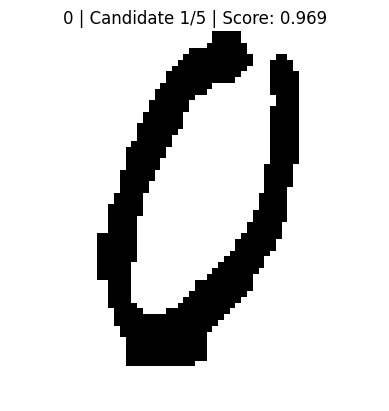

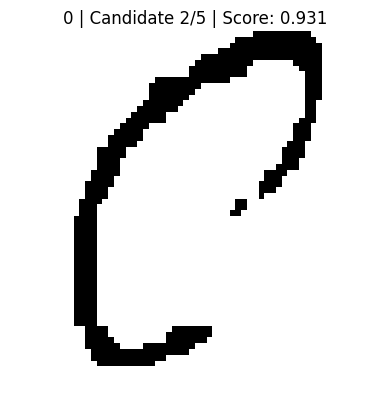

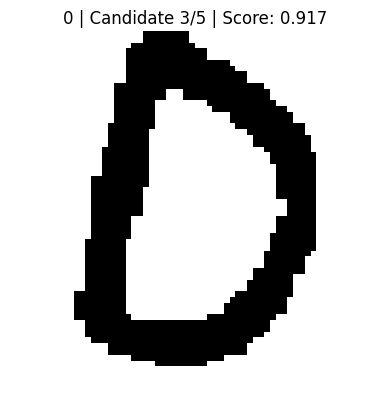

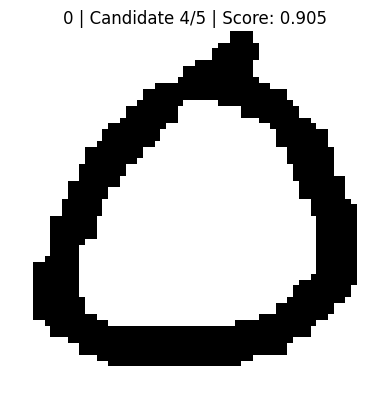

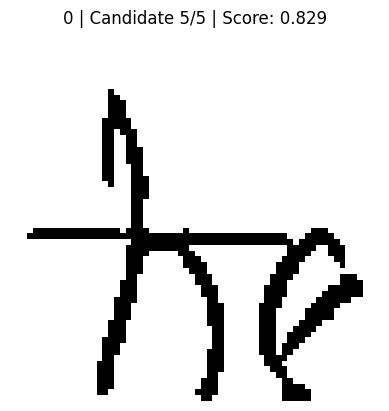

Select best candidate index (1-5) or 'skip': 4
✅ Selected Candidate 4/5

🔤 Label: 1


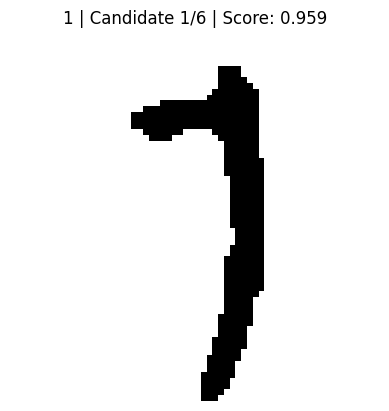

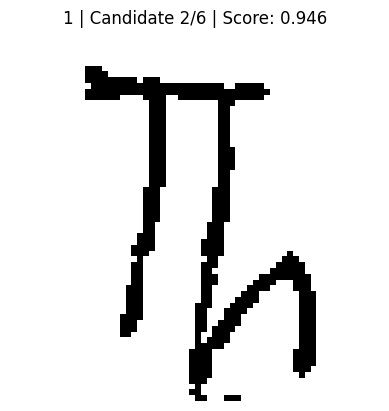

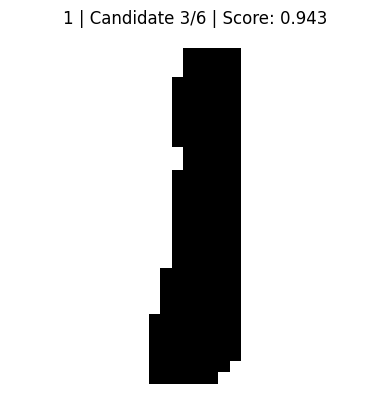

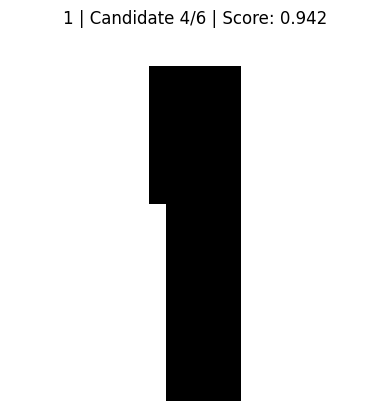

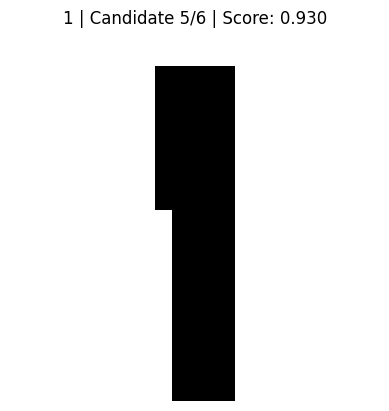

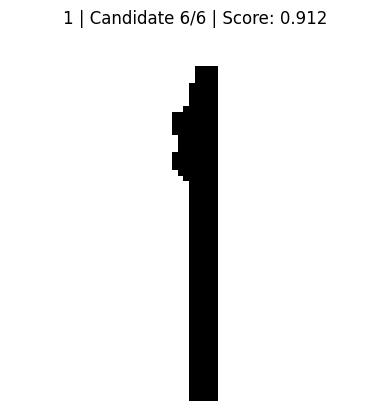

Select best candidate index (1-6) or 'skip': 6
✅ Selected Candidate 6/6

🔤 Label: 2


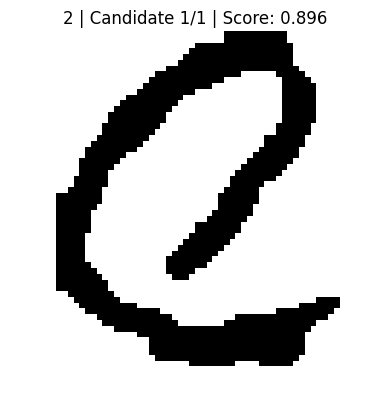

Select best candidate index (1-1) or 'skip': skip
⚠️ Skipped label: 2

🔤 Label: 4


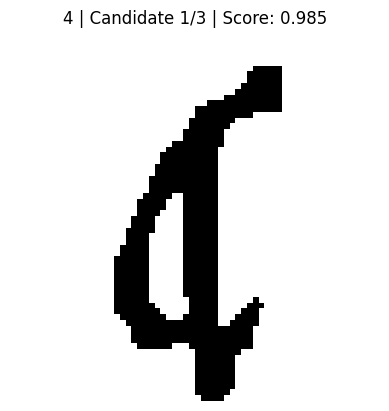

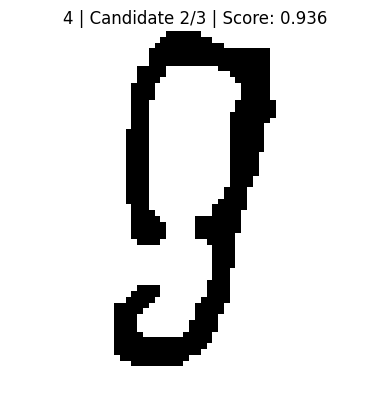

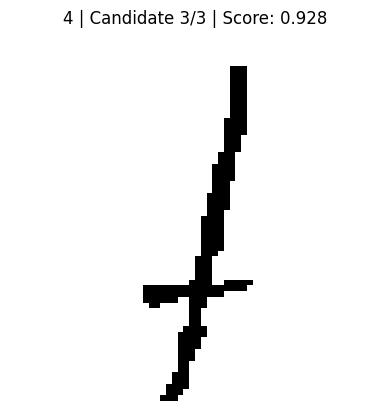

Select best candidate index (1-3) or 'skip': 1
✅ Selected Candidate 1/3

🔤 Label: 6


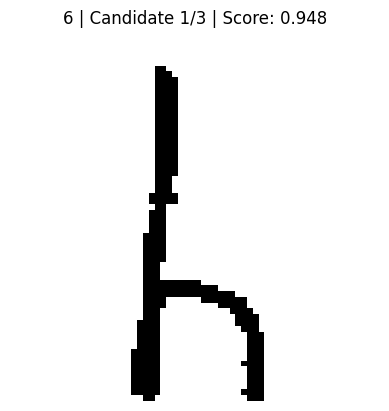

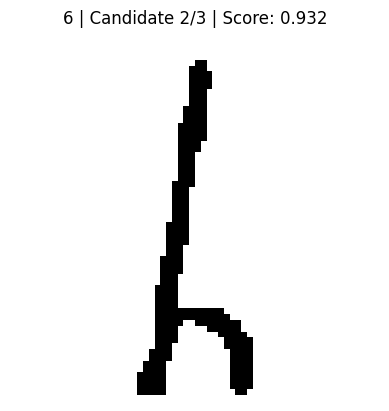

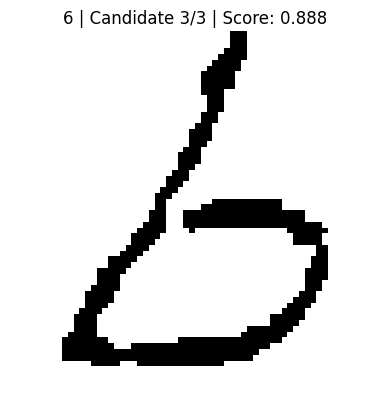

Select best candidate index (1-3) or 'skip': 3
✅ Selected Candidate 3/3

🔤 Label: 7


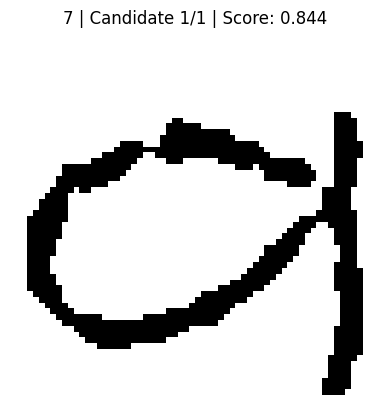

Select best candidate index (1-1) or 'skip': skip
⚠️ Skipped label: 7

🔤 Label: C


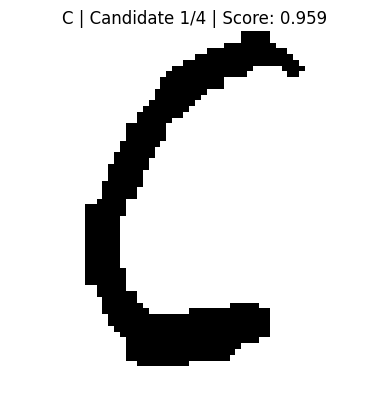

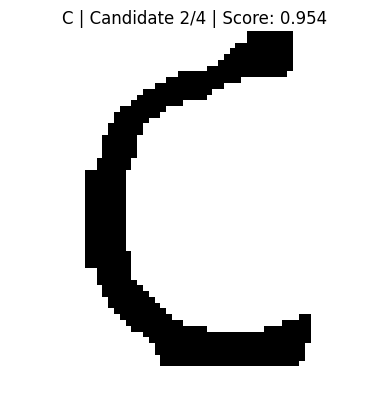

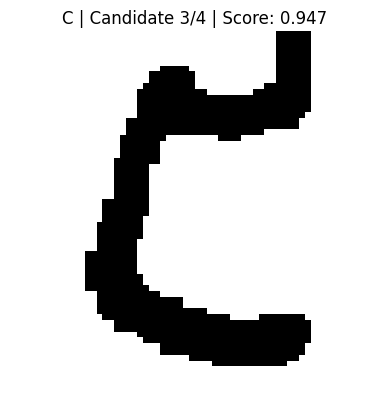

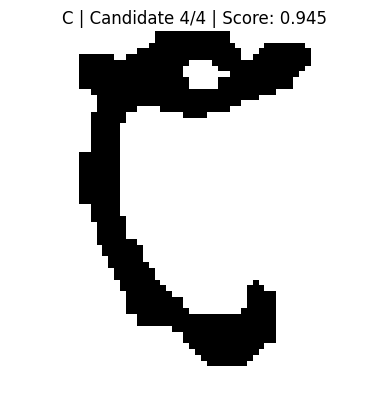

Select best candidate index (1-4) or 'skip': 1
✅ Selected Candidate 1/4

🔤 Label: G


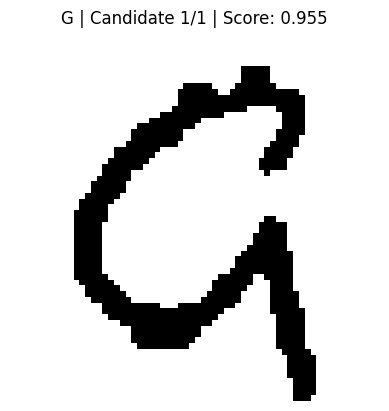

Select best candidate index (1-1) or 'skip': 1
✅ Selected Candidate 1/1

🔤 Label: L


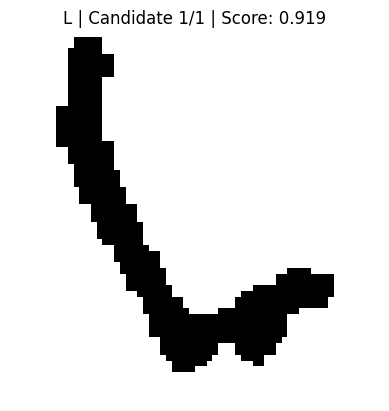

Select best candidate index (1-1) or 'skip': 1
✅ Selected Candidate 1/1

🔤 Label: N


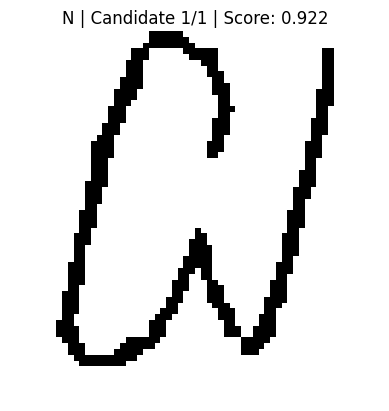

Select best candidate index (1-1) or 'skip': skip
⚠️ Skipped label: N

🔤 Label: P


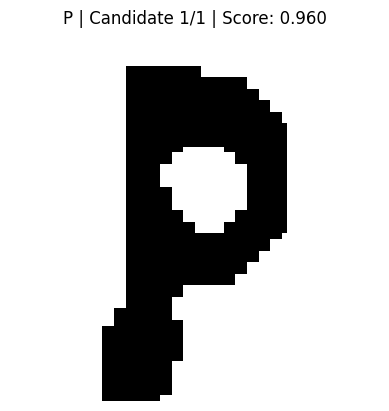

Select best candidate index (1-1) or 'skip': 1
✅ Selected Candidate 1/1

🔤 Label: Q


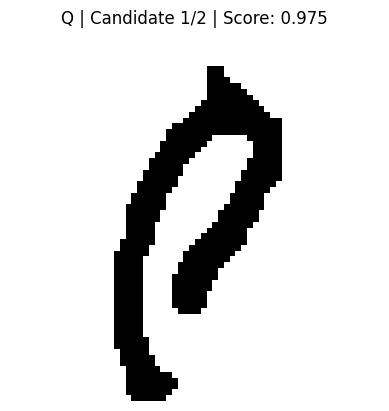

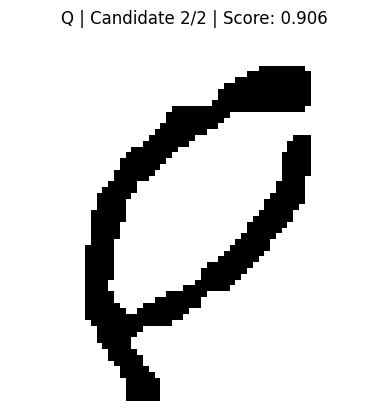

Select best candidate index (1-2) or 'skip': 2
✅ Selected Candidate 2/2

🔤 Label: S


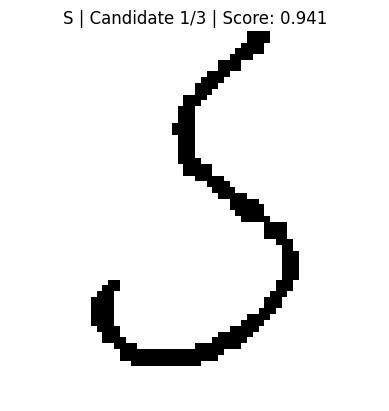

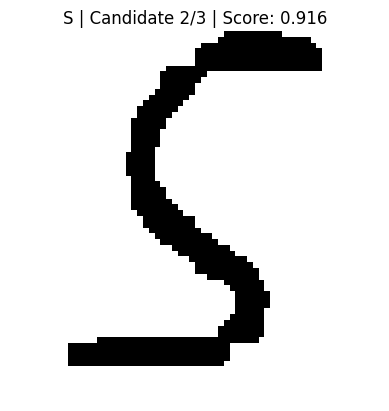

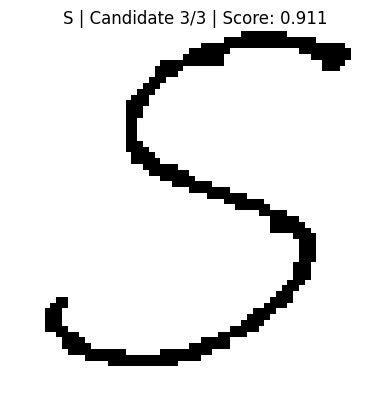

Select best candidate index (1-3) or 'skip': 2
✅ Selected Candidate 2/3

🔤 Label: U


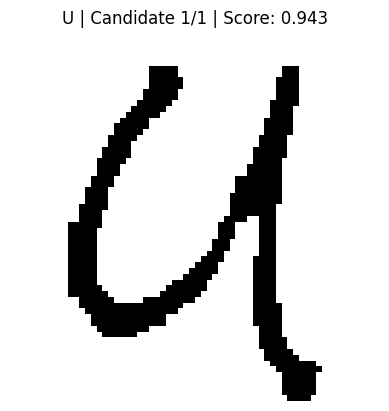

Select best candidate index (1-1) or 'skip': 1
✅ Selected Candidate 1/1

🔤 Label: W


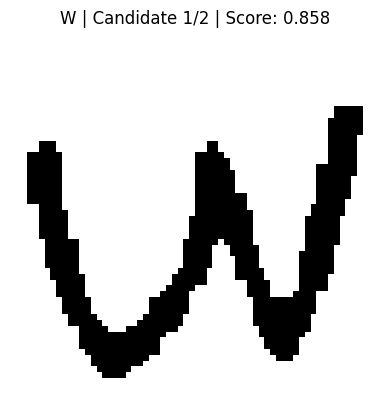

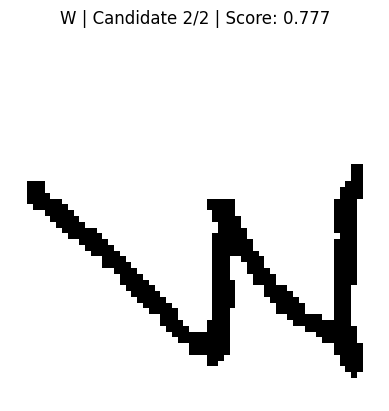

Select best candidate index (1-2) or 'skip': 1
✅ Selected Candidate 1/2

🔤 Label: Y


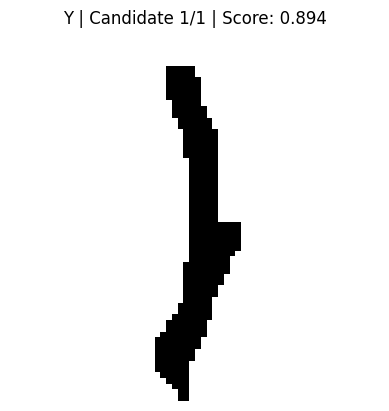

Select best candidate index (1-1) or 'skip': skip
⚠️ Skipped label: Y

🔤 Label: a


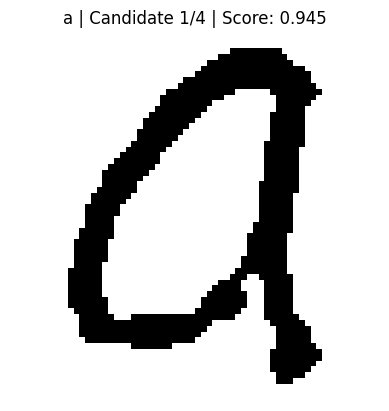

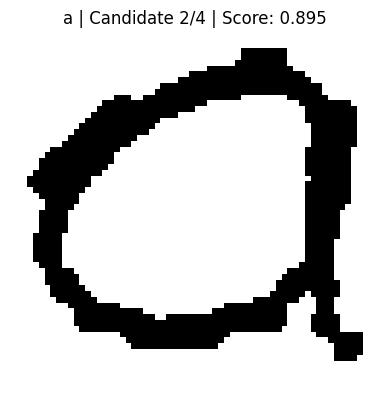

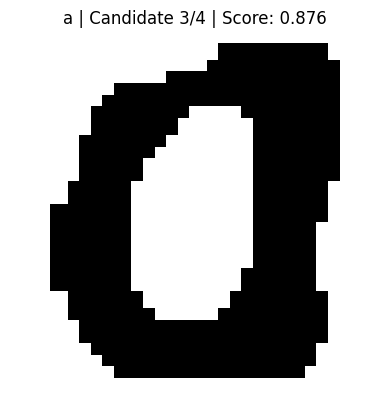

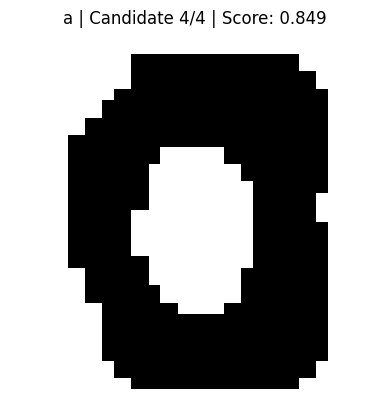

Select best candidate index (1-4) or 'skip': 2
✅ Selected Candidate 2/4

🔤 Label: d


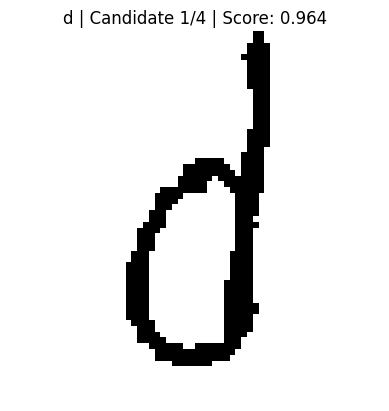

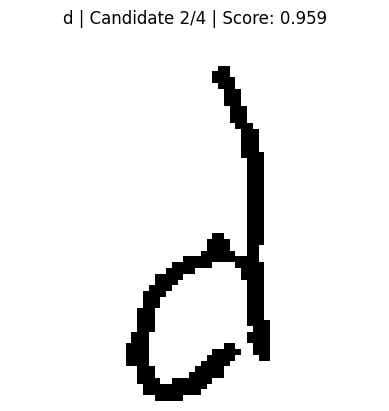

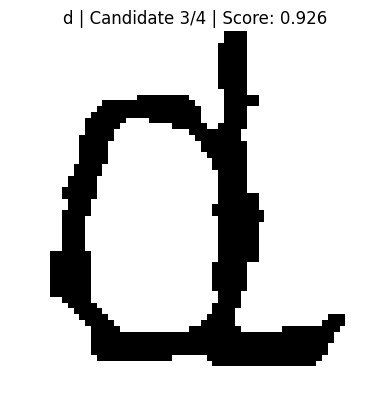

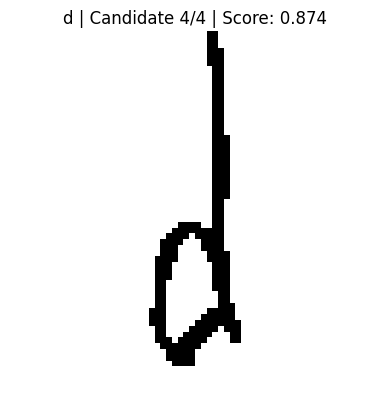

Select best candidate index (1-4) or 'skip': 1
✅ Selected Candidate 1/4

🔤 Label: e


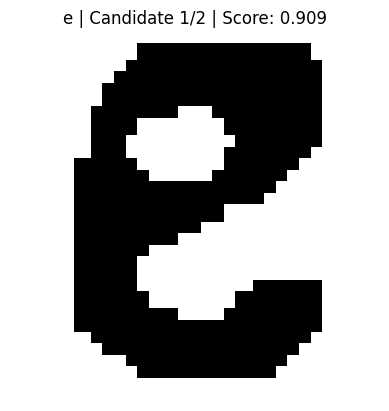

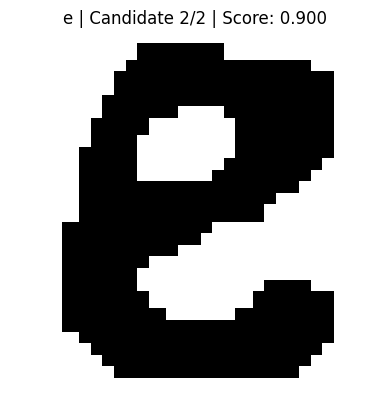

Select best candidate index (1-2) or 'skip': 2
✅ Selected Candidate 2/2

🔤 Label: g


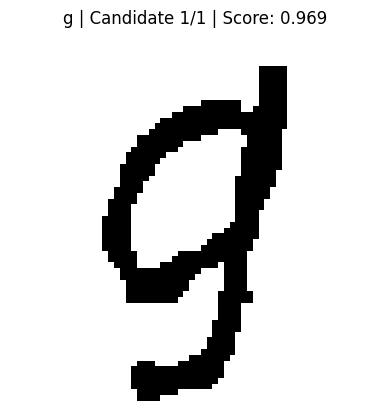

Select best candidate index (1-1) or 'skip': 1
✅ Selected Candidate 1/1

🔤 Label: h


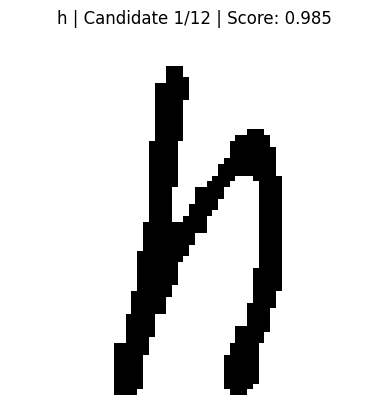

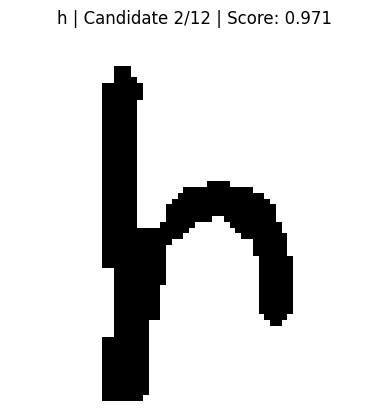

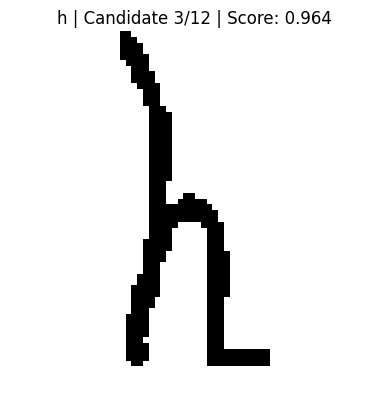

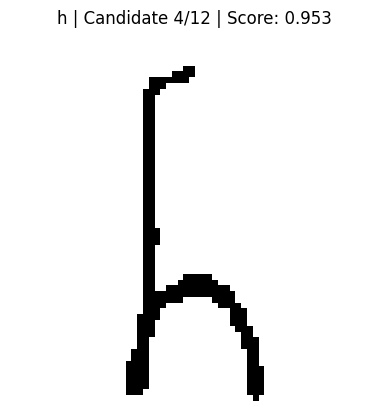

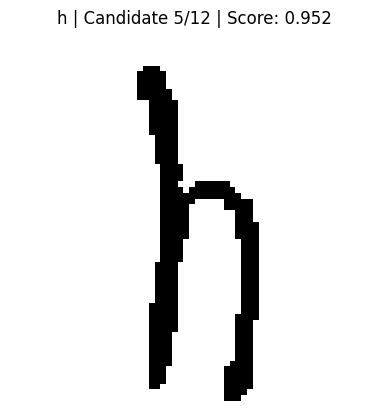

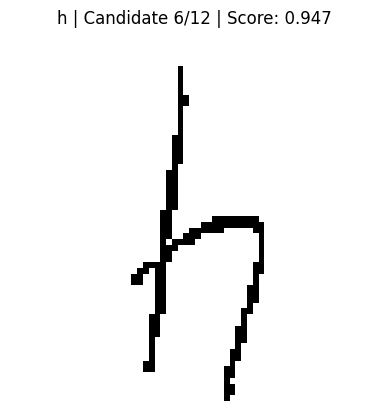

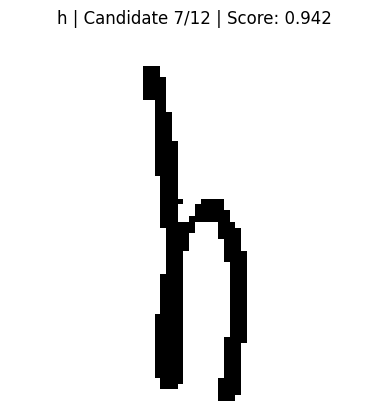

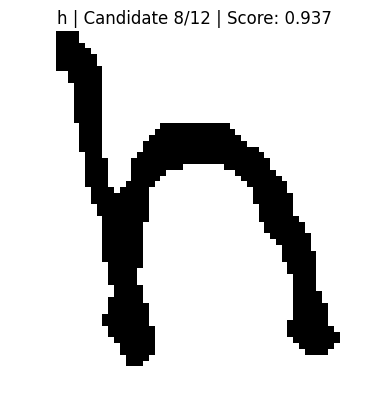

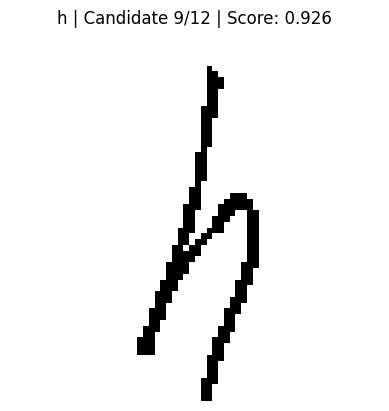

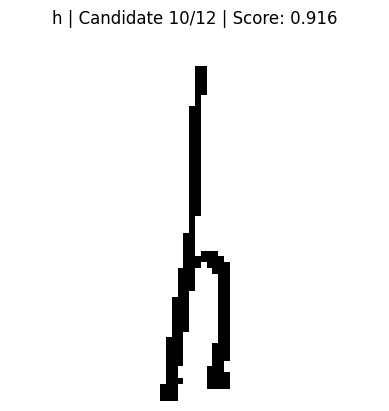

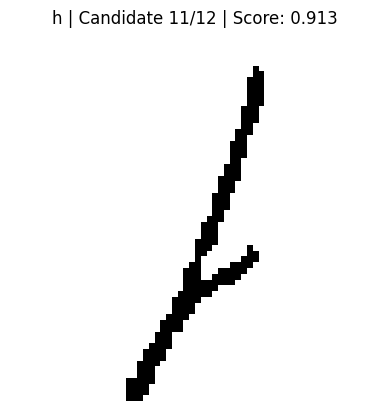

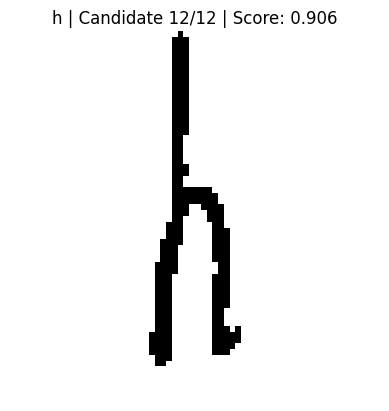

Select best candidate index (1-12) or 'skip': 3
✅ Selected Candidate 3/12

🔤 Label: k


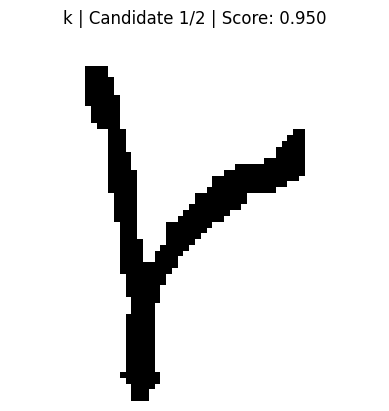

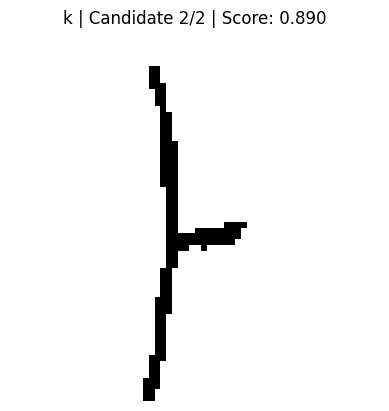

Select best candidate index (1-2) or 'skip': skip
⚠️ Skipped label: k

🔤 Label: n


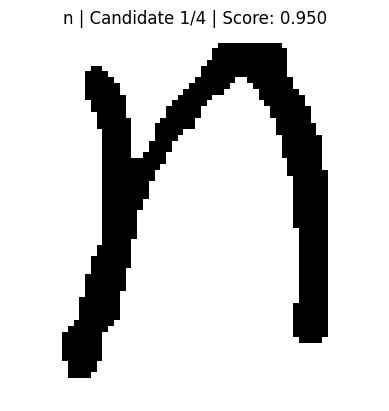

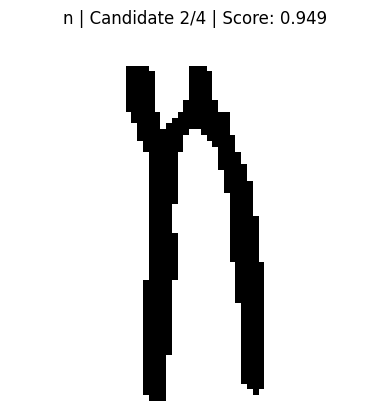

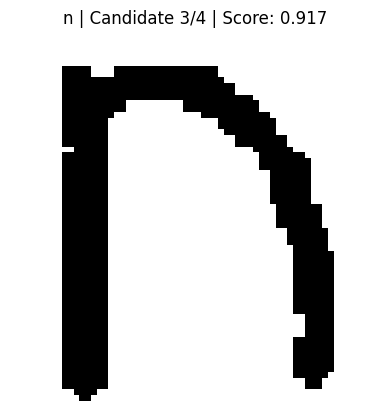

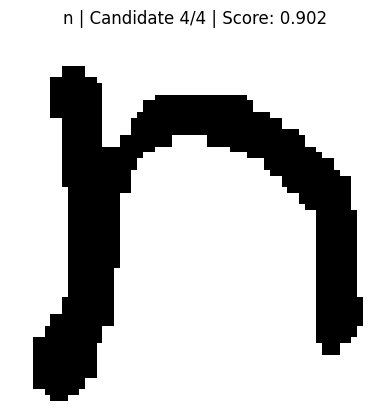

Select best candidate index (1-4) or 'skip': 1
✅ Selected Candidate 1/4

🔤 Label: p


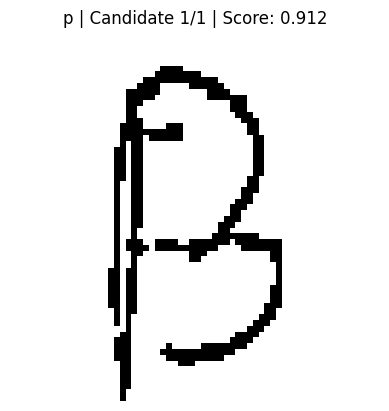

Select best candidate index (1-1) or 'skip': skip
⚠️ Skipped label: p

🔤 Label: t


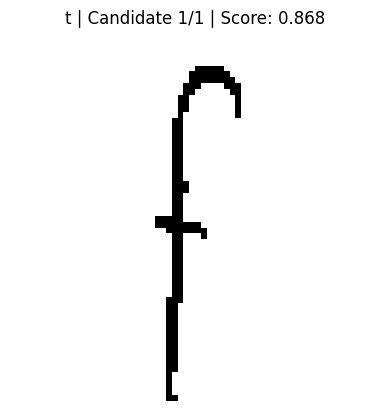

Select best candidate index (1-1) or 'skip': skip
⚠️ Skipped label: t

📂 Processing: kid2

🔤 Label: 0


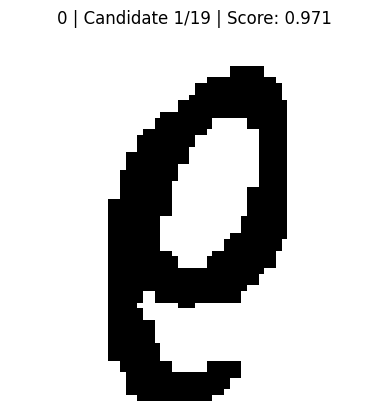

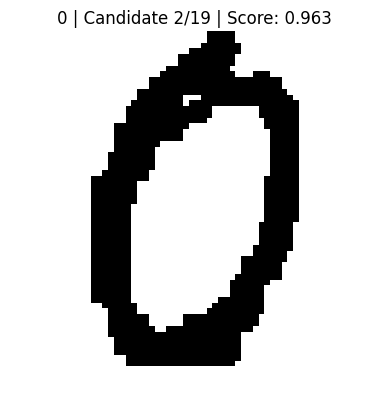

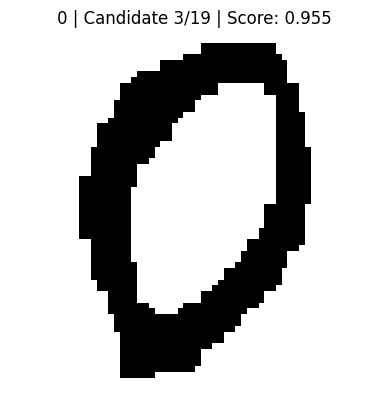

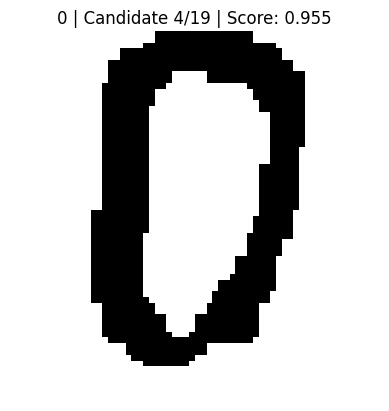

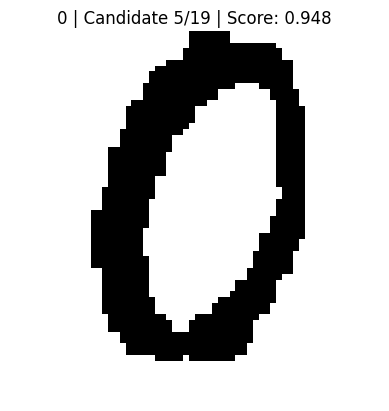

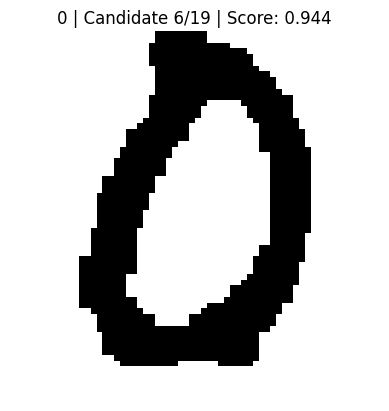

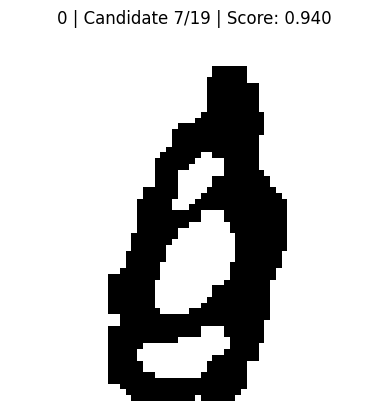

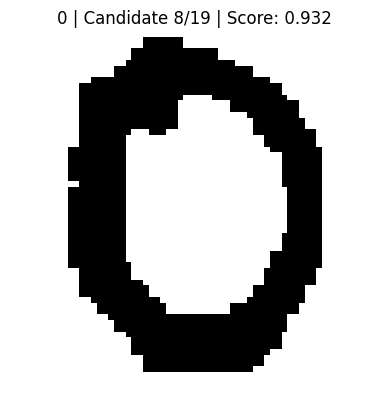

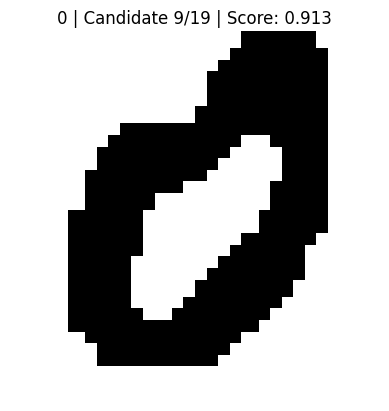

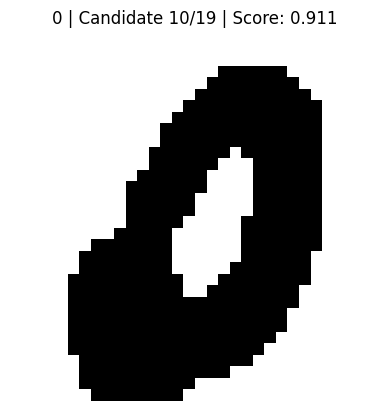

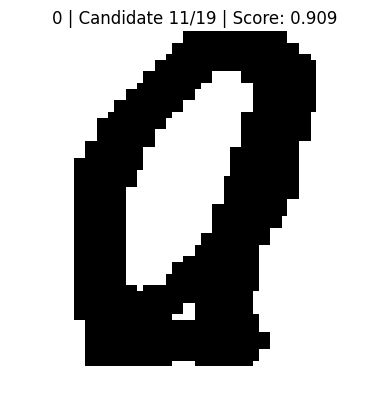

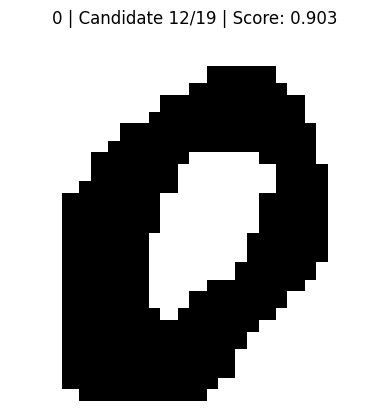

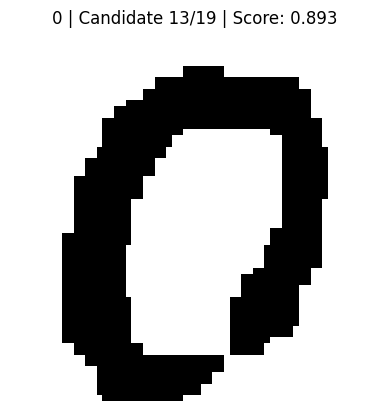

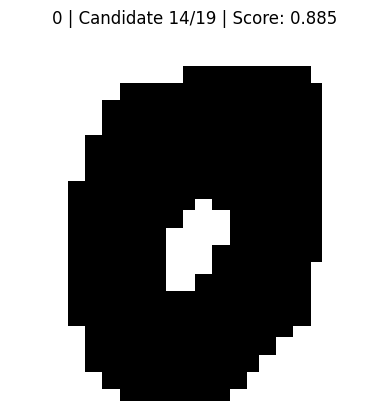

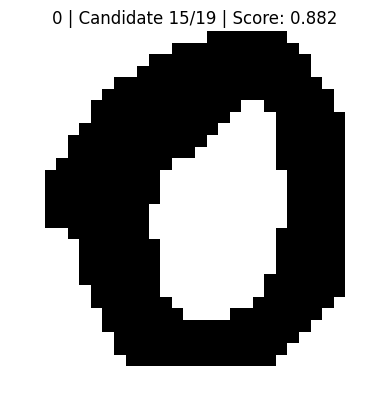

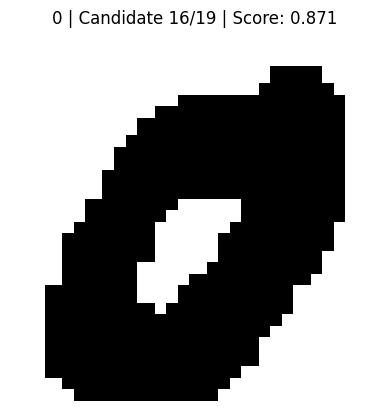

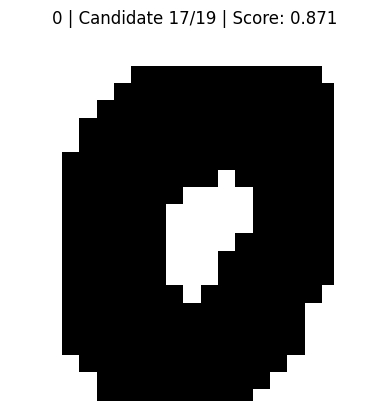

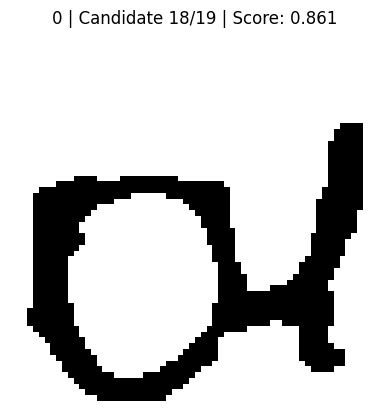

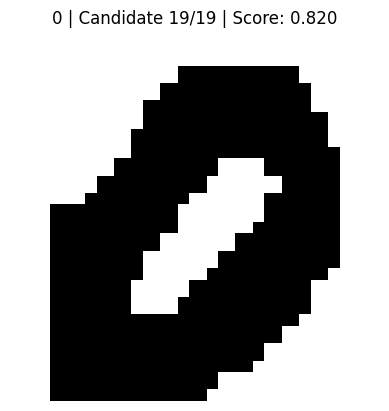

Select best candidate index (1-19) or 'skip': 3
✅ Selected Candidate 3/19

🔤 Label: 1


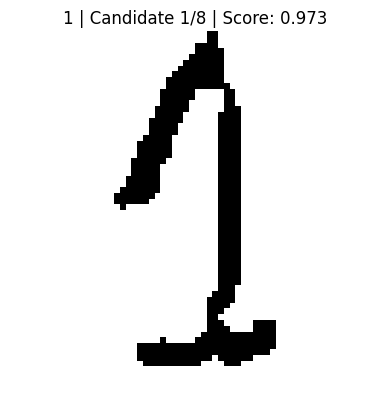

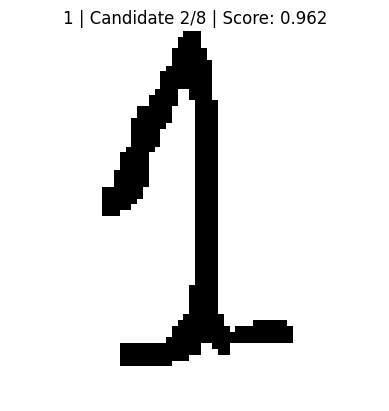

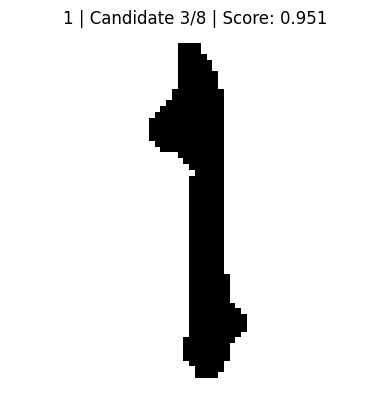

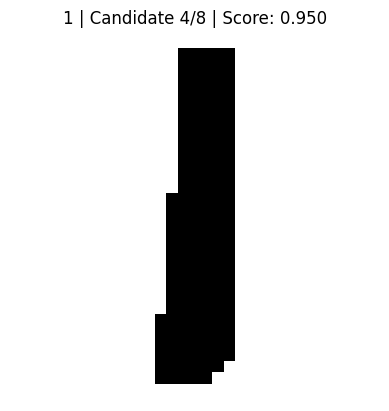

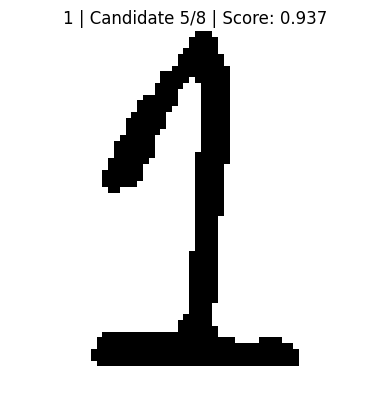

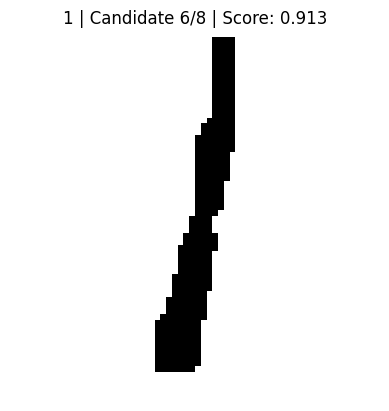

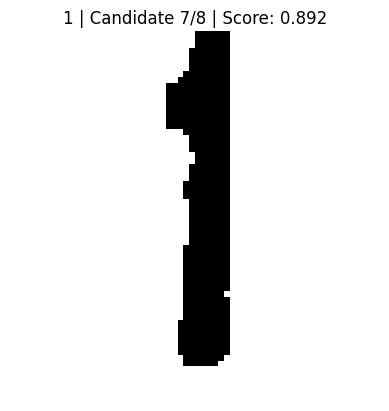

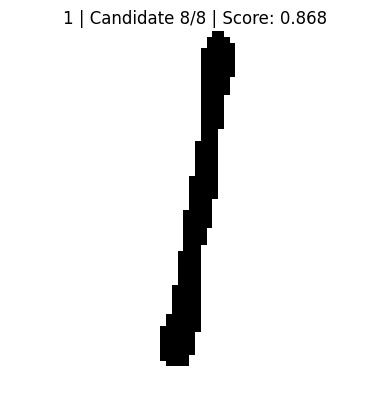

Select best candidate index (1-8) or 'skip': 5
✅ Selected Candidate 5/8

🔤 Label: 2


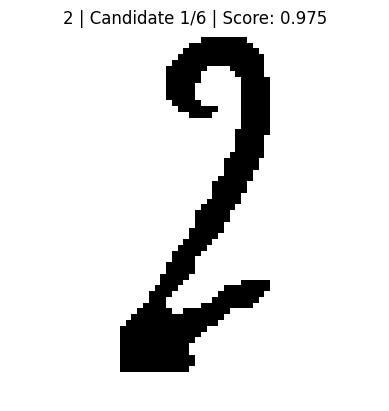

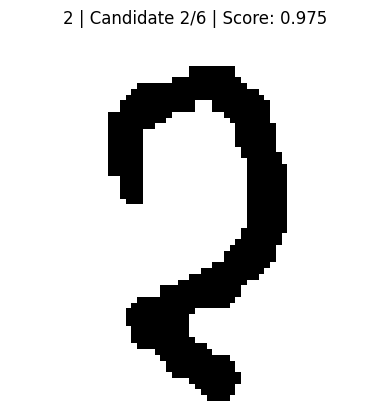

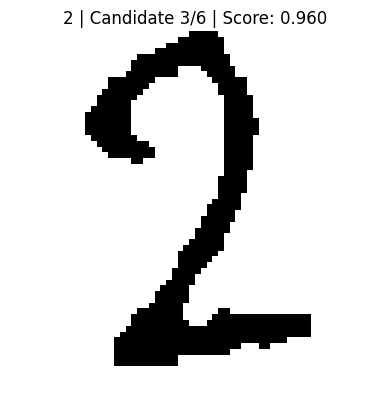

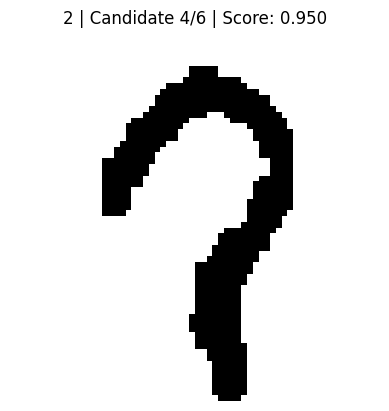

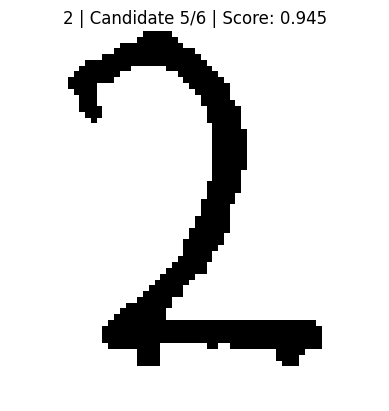

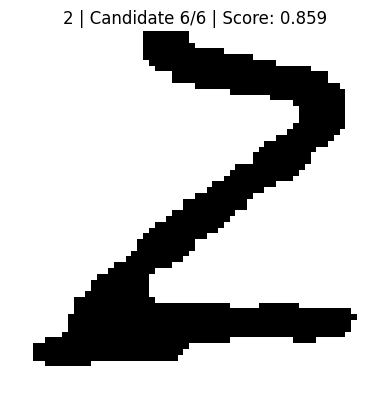

Select best candidate index (1-6) or 'skip': 3
✅ Selected Candidate 3/6

🔤 Label: 3


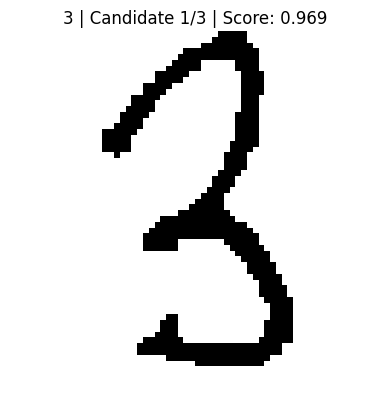

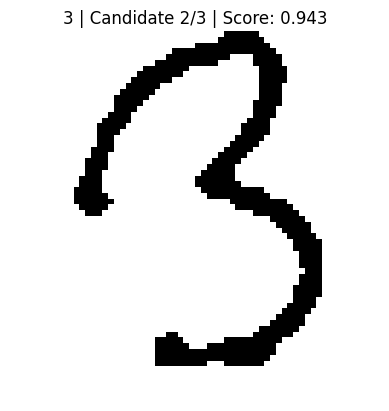

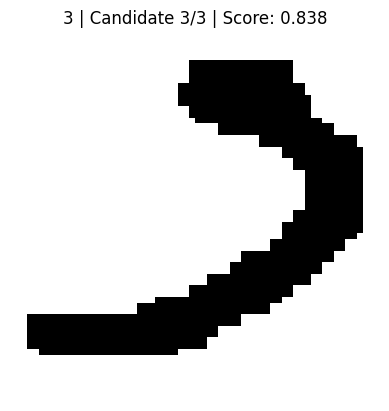

Select best candidate index (1-3) or 'skip': 1
✅ Selected Candidate 1/3

🔤 Label: 4


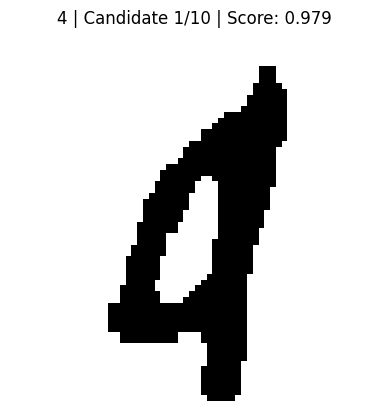

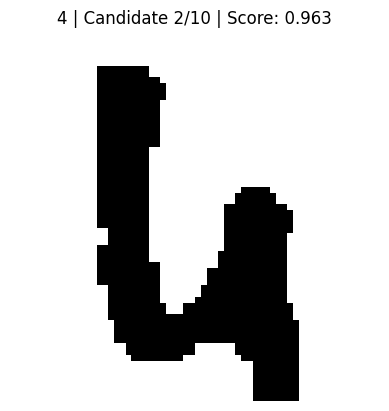

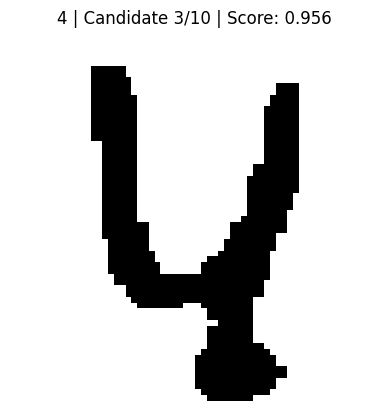

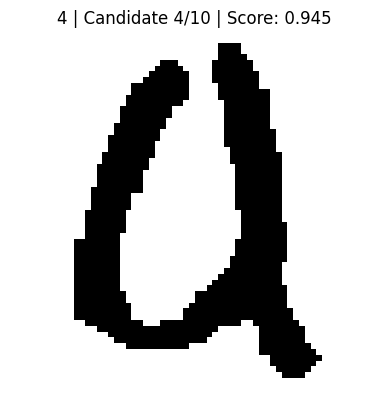

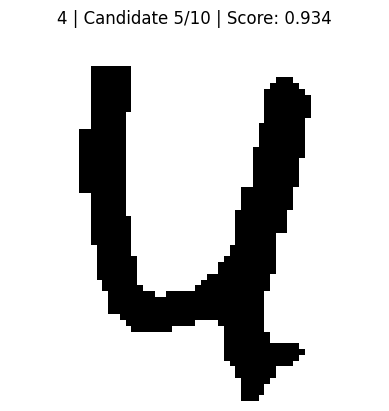

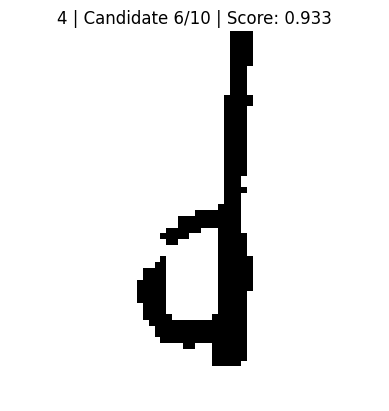

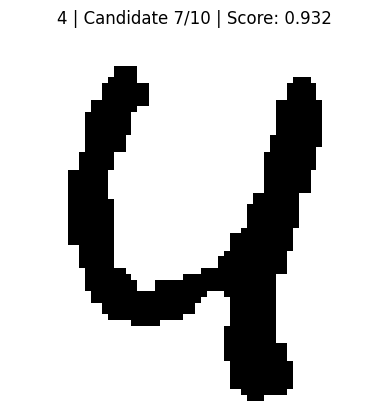

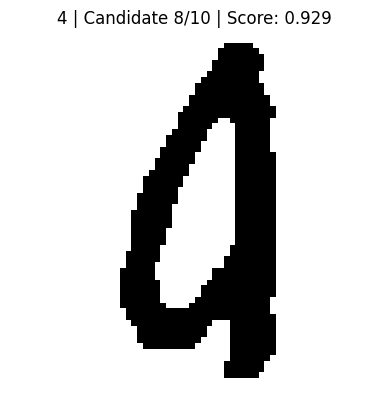

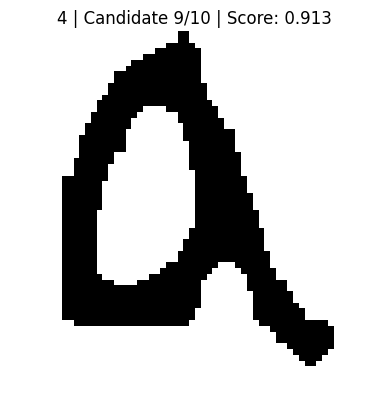

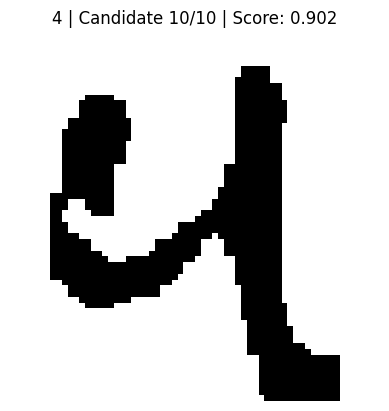

Select best candidate index (1-10) or 'skip': 7
✅ Selected Candidate 7/10

🔤 Label: 5


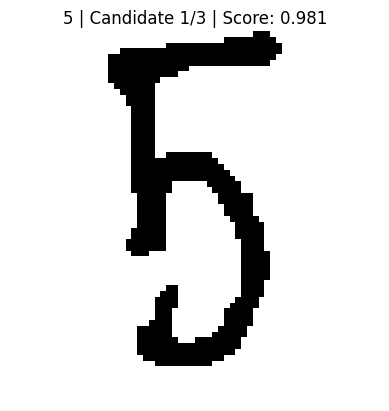

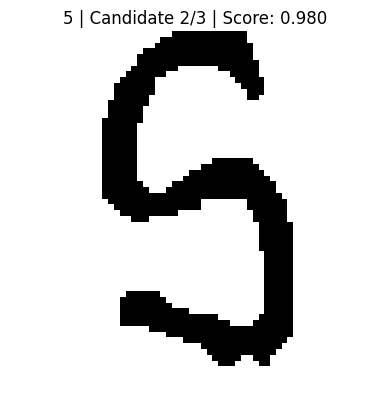

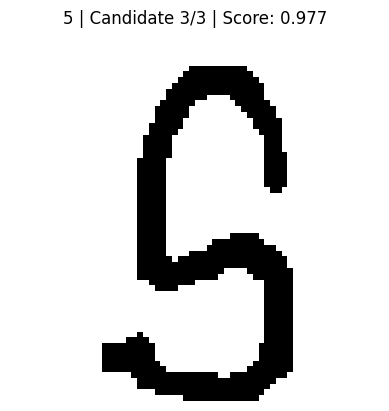

Select best candidate index (1-3) or 'skip': 1
✅ Selected Candidate 1/3

🔤 Label: 6


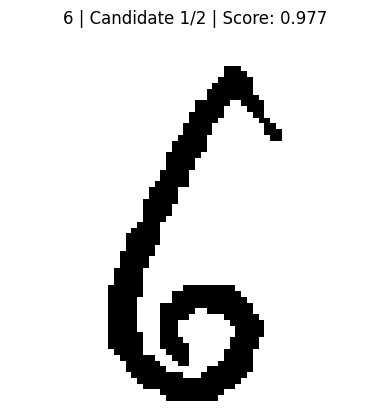

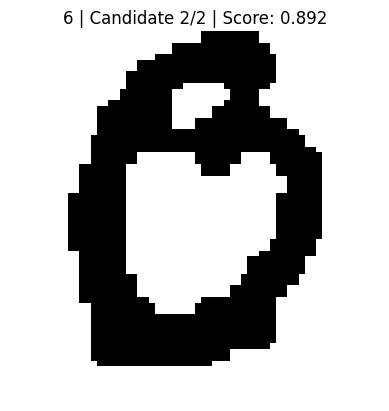

Select best candidate index (1-2) or 'skip': 1
✅ Selected Candidate 1/2

🔤 Label: 8


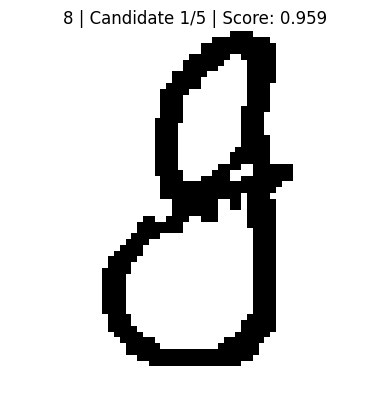

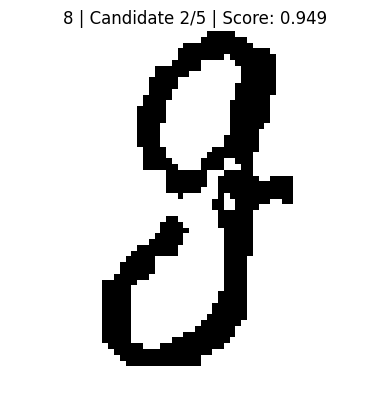

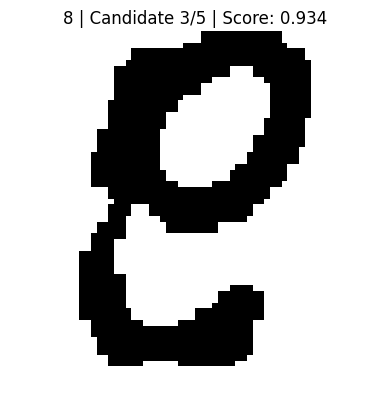

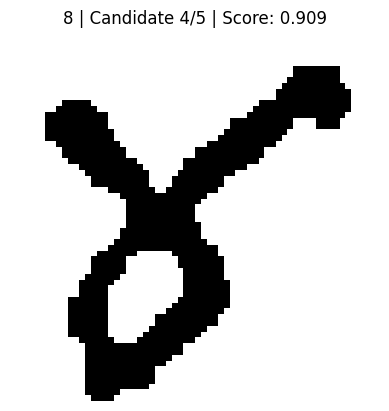

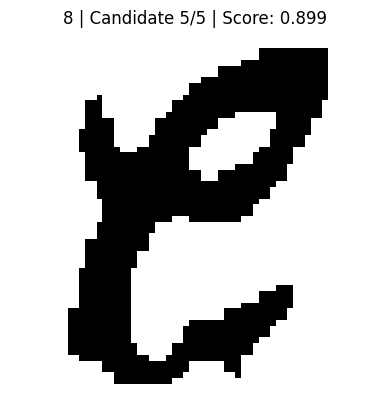

Select best candidate index (1-5) or 'skip': 1
✅ Selected Candidate 1/5

🔤 Label: 9


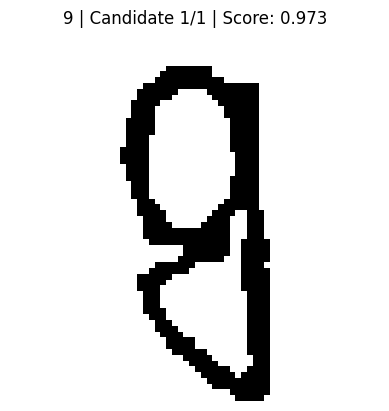

Select best candidate index (1-1) or 'skip': skip
⚠️ Skipped label: 9

🔤 Label: A


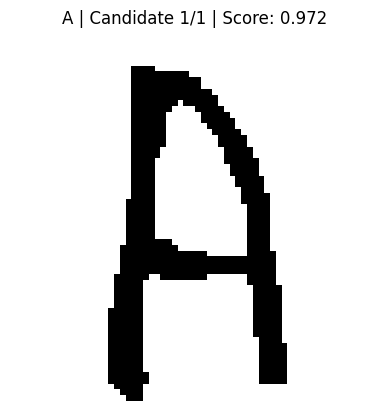

Select best candidate index (1-1) or 'skip': 1
✅ Selected Candidate 1/1

🔤 Label: C


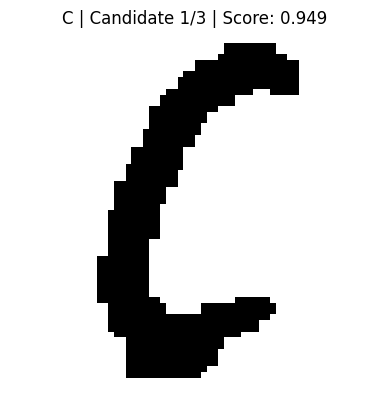

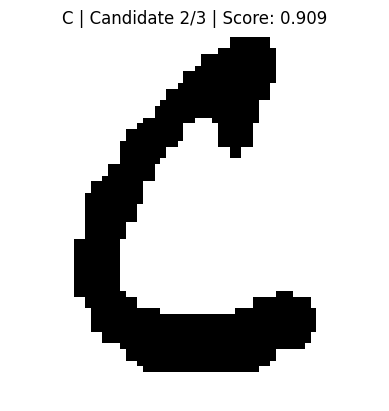

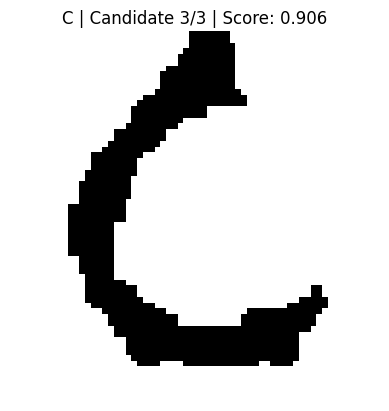

Select best candidate index (1-3) or 'skip': 2
✅ Selected Candidate 2/3

🔤 Label: D


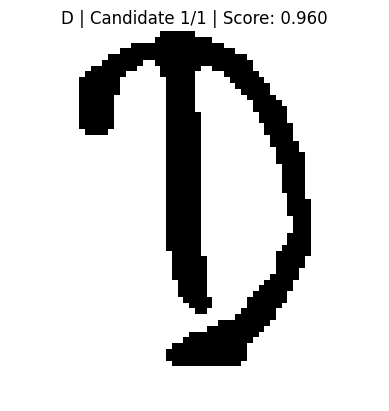

Select best candidate index (1-1) or 'skip': 1
✅ Selected Candidate 1/1

🔤 Label: F


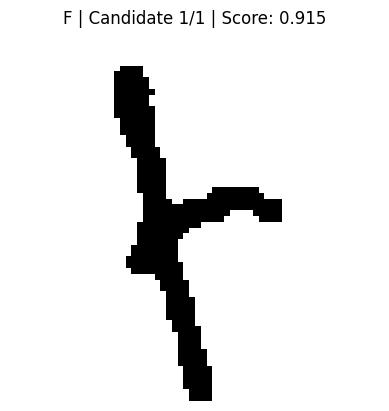

Select best candidate index (1-1) or 'skip': skip
⚠️ Skipped label: F

🔤 Label: I


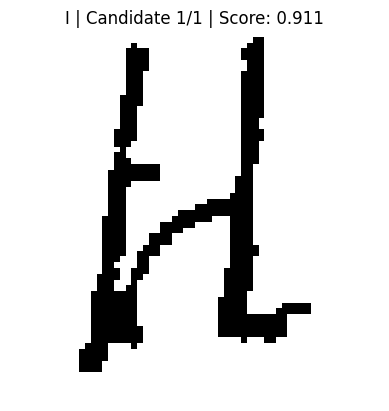

Select best candidate index (1-1) or 'skip': skip
⚠️ Skipped label: I

🔤 Label: K


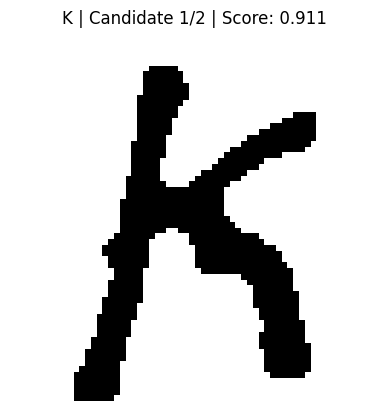

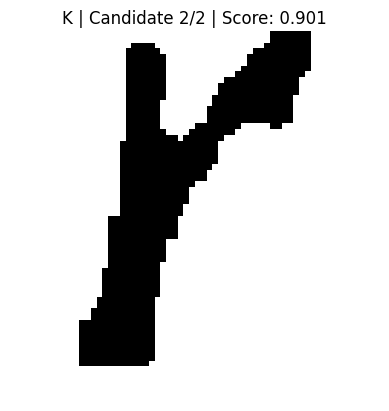

Select best candidate index (1-2) or 'skip': 1
✅ Selected Candidate 1/2

🔤 Label: M


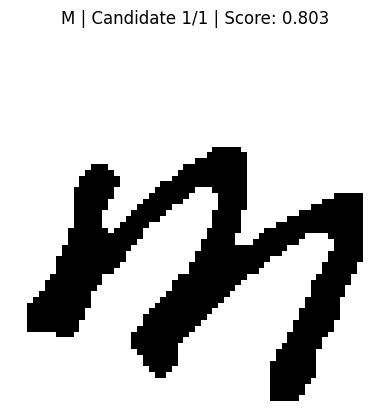

Select best candidate index (1-1) or 'skip': 1
✅ Selected Candidate 1/1

🔤 Label: P


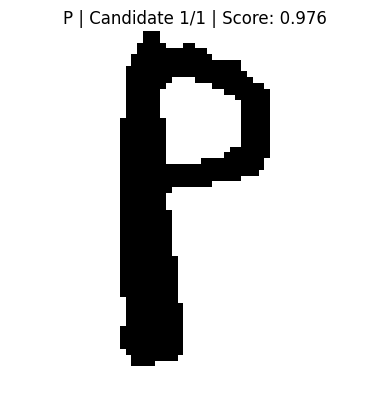

Select best candidate index (1-1) or 'skip': 1
✅ Selected Candidate 1/1

🔤 Label: S


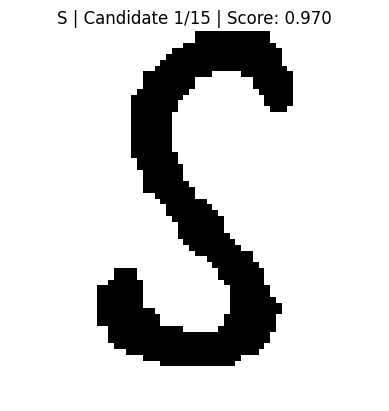

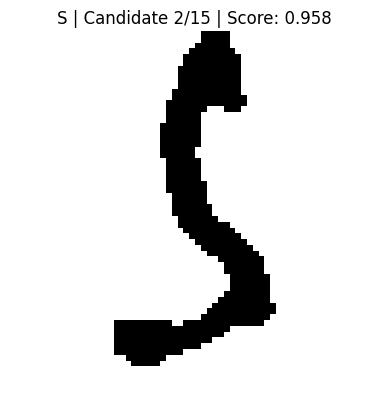

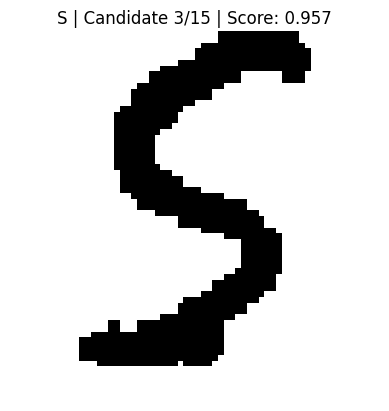

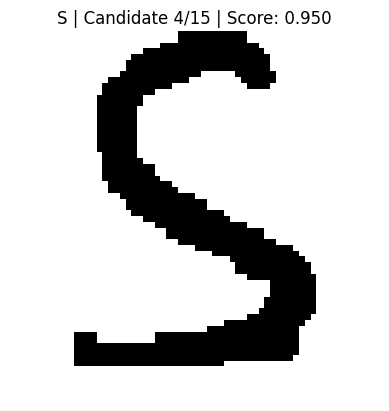

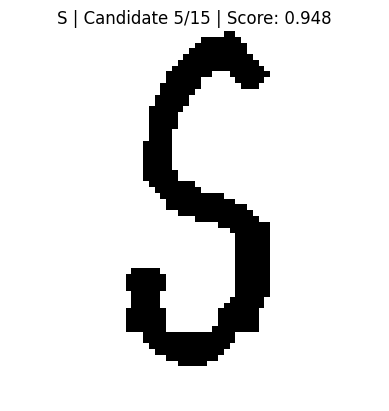

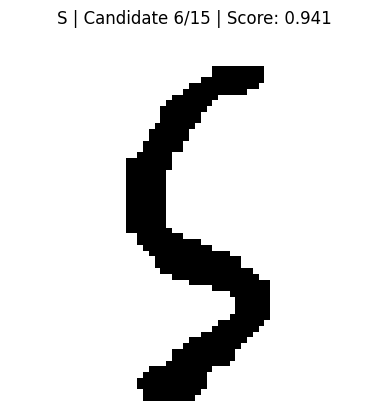

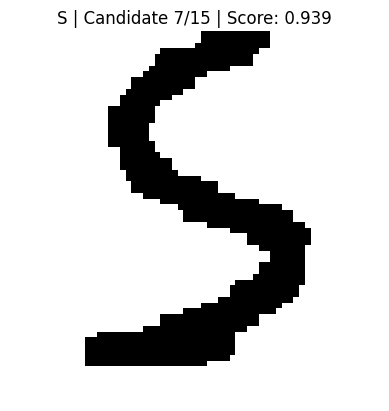

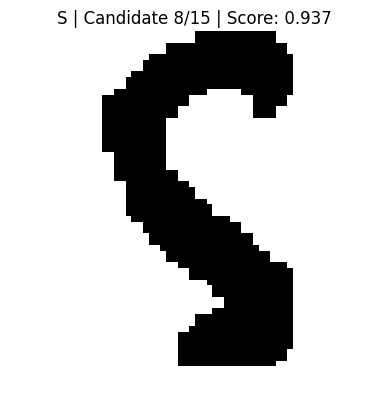

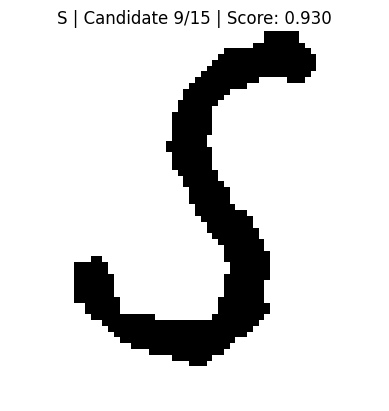

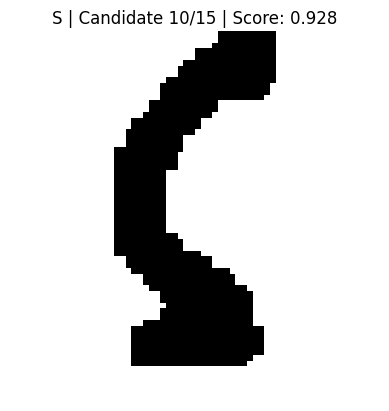

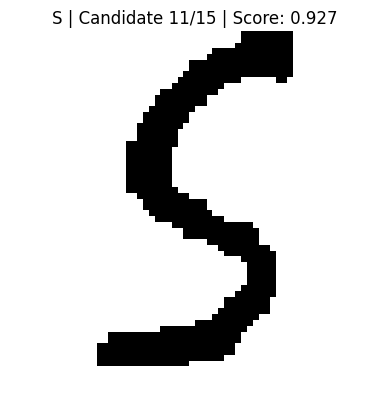

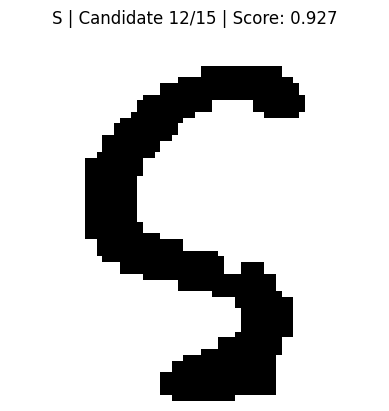

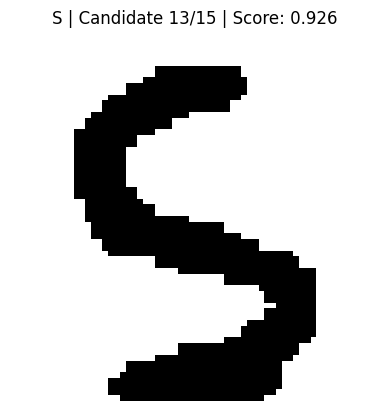

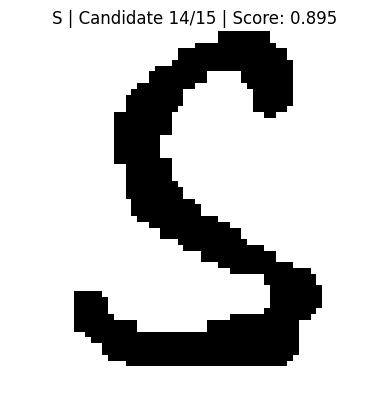

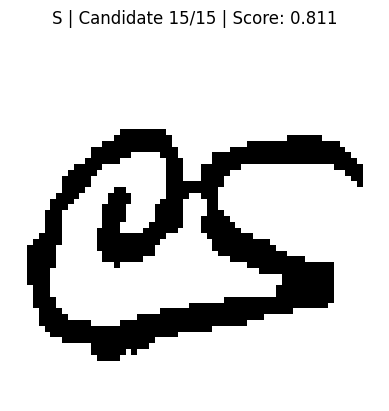

Select best candidate index (1-15) or 'skip': 1
✅ Selected Candidate 1/15

🔤 Label: V


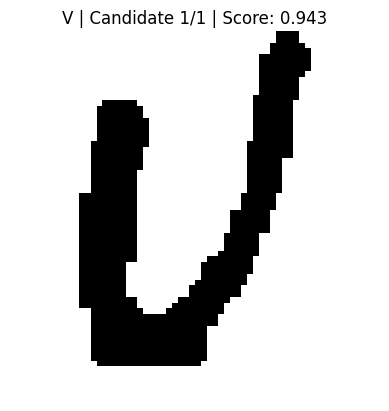

Select best candidate index (1-1) or 'skip': 1
✅ Selected Candidate 1/1

🔤 Label: W


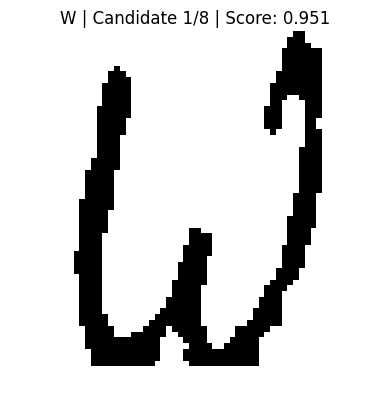

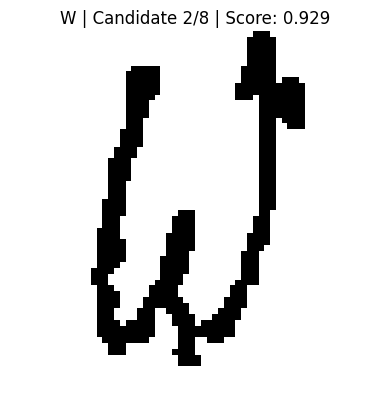

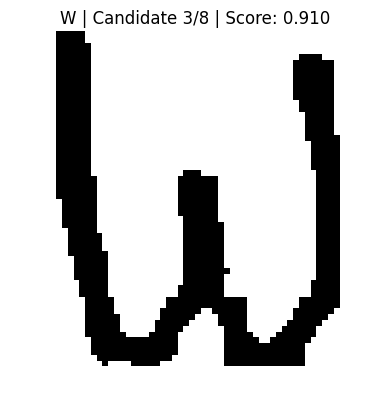

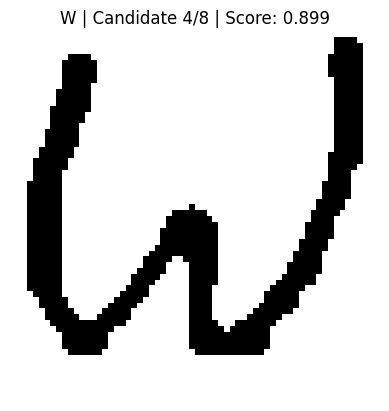

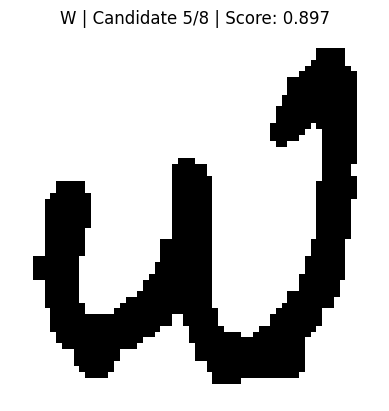

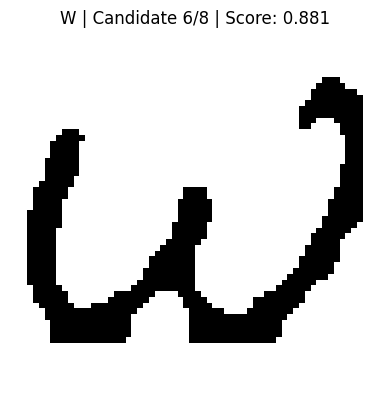

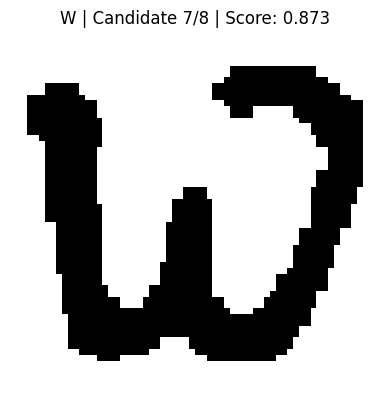

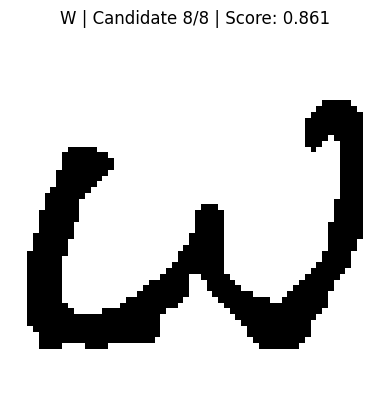

Select best candidate index (1-8) or 'skip': 3
✅ Selected Candidate 3/8

🔤 Label: X


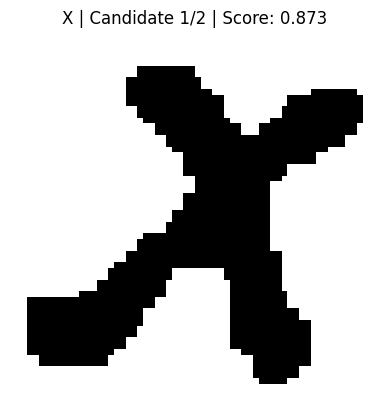

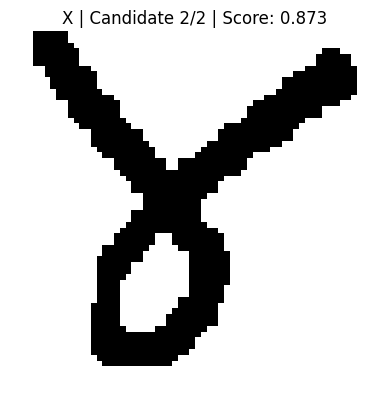

Select best candidate index (1-2) or 'skip': 1
✅ Selected Candidate 1/2

🔤 Label: Y


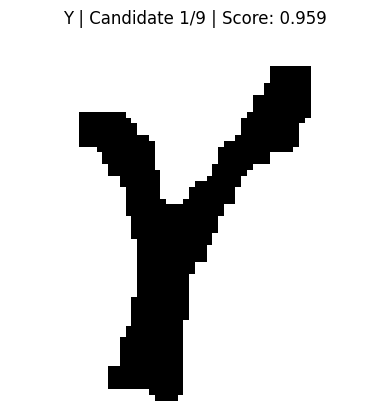

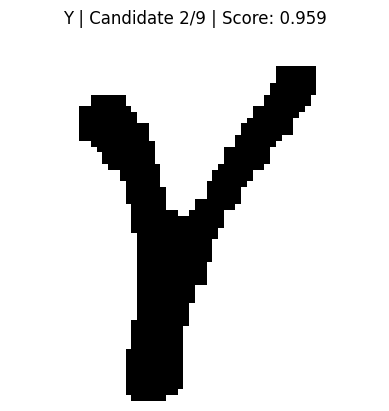

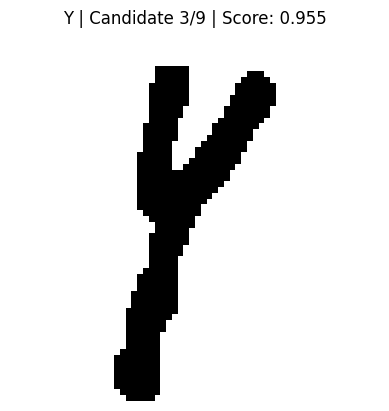

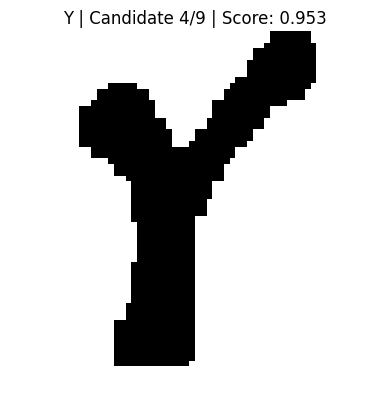

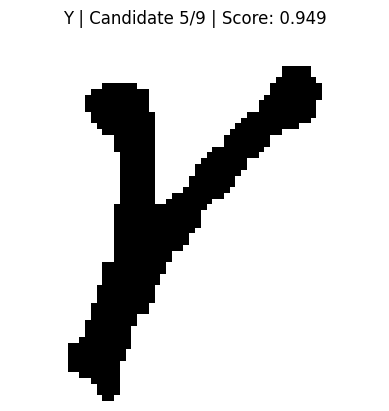

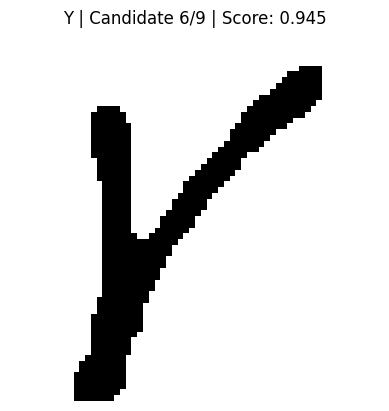

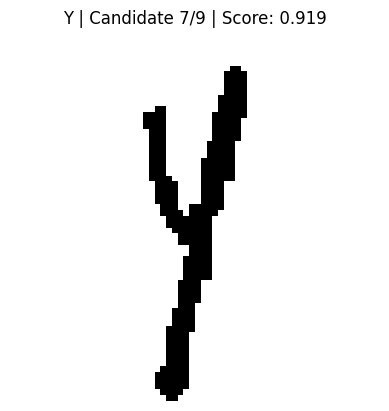

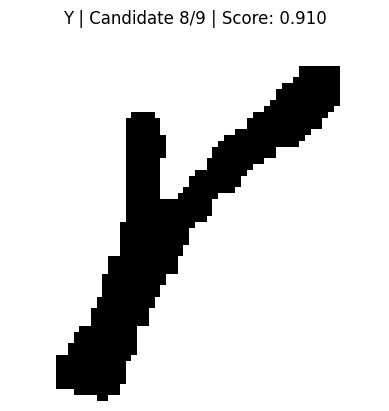

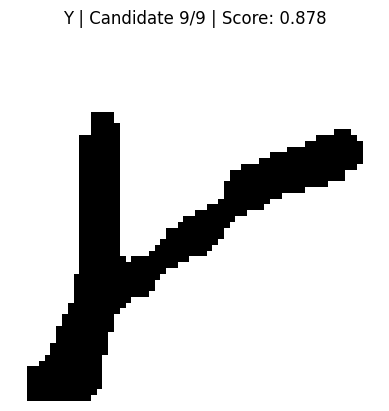

Select best candidate index (1-9) or 'skip': 2
✅ Selected Candidate 2/9

🔤 Label: a


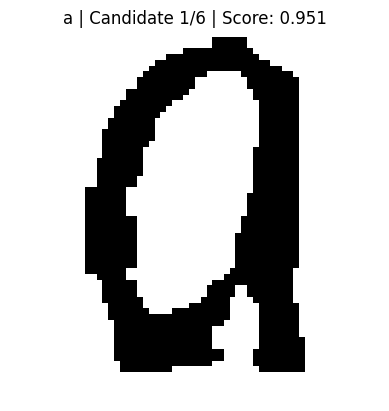

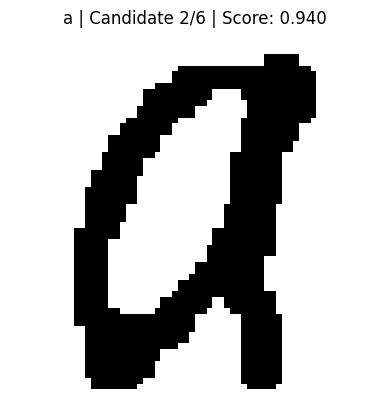

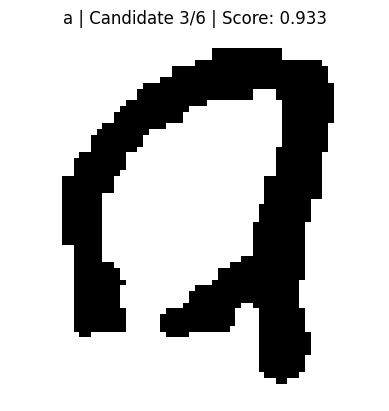

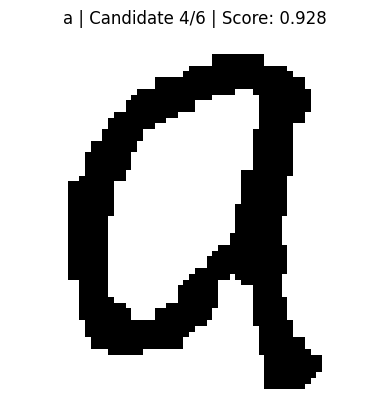

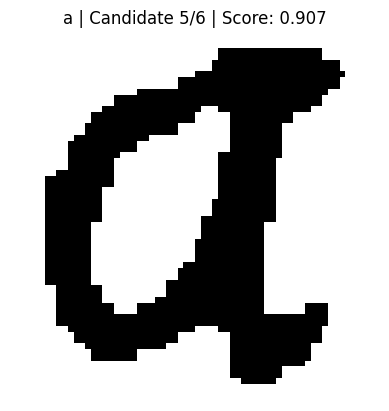

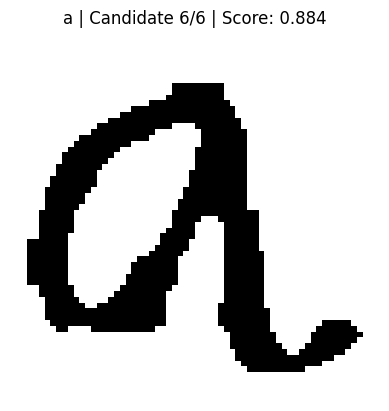

Select best candidate index (1-6) or 'skip': 5
✅ Selected Candidate 5/6

🔤 Label: b


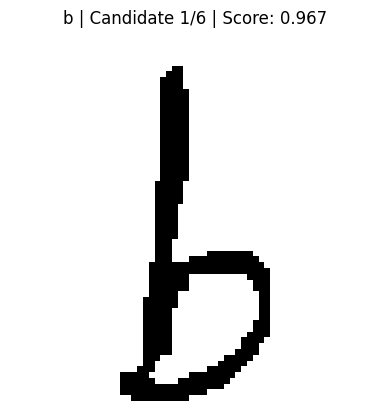

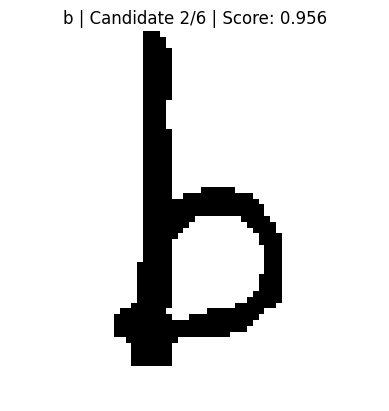

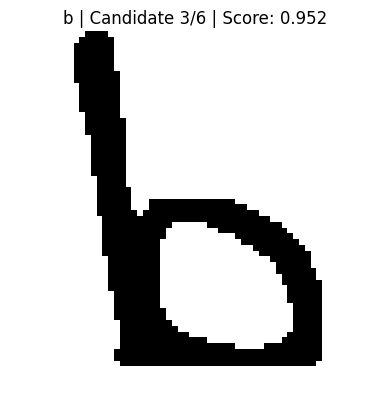

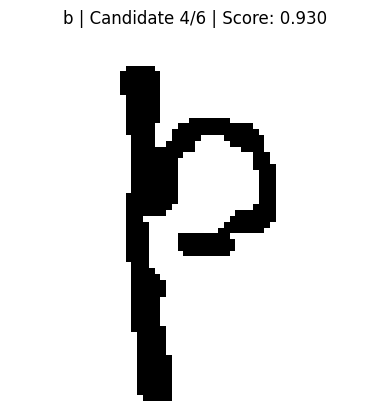

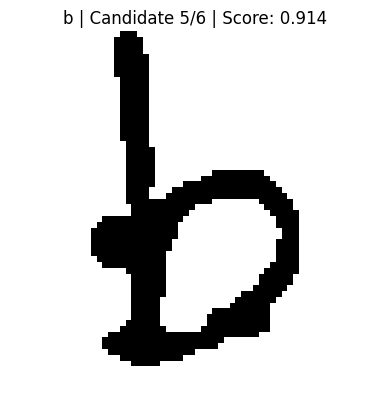

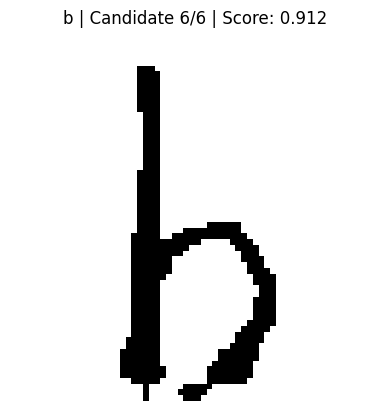

Select best candidate index (1-6) or 'skip': 3
✅ Selected Candidate 3/6

🔤 Label: d


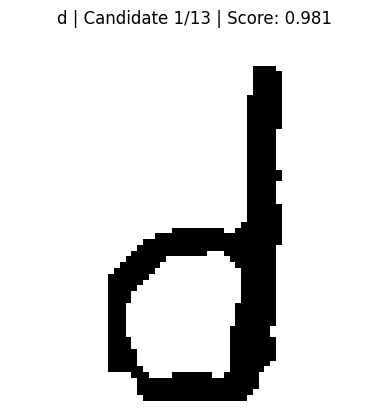

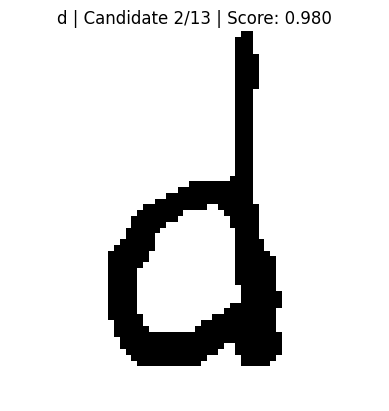

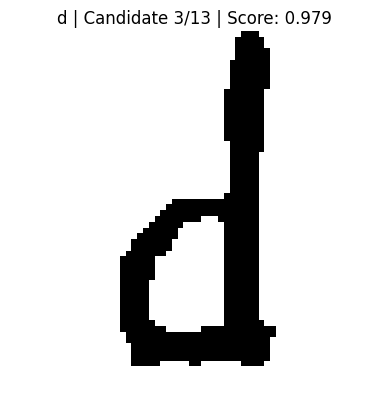

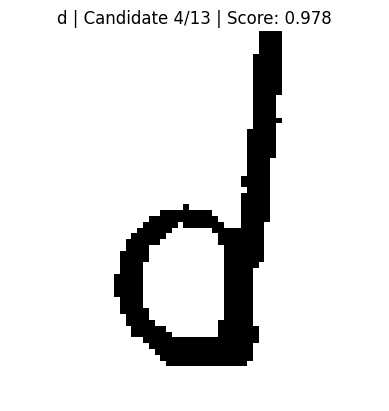

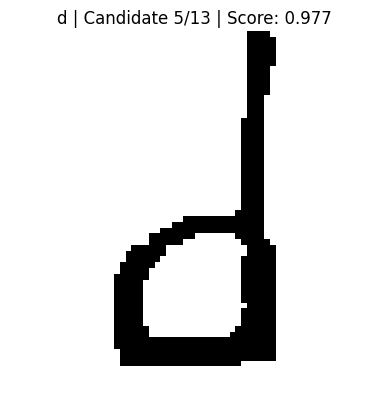

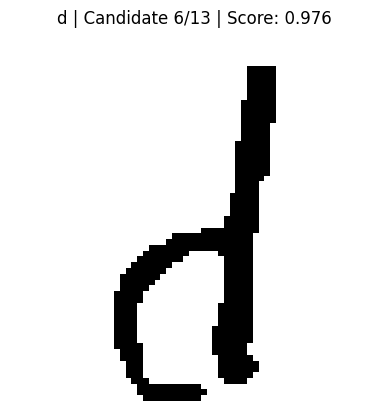

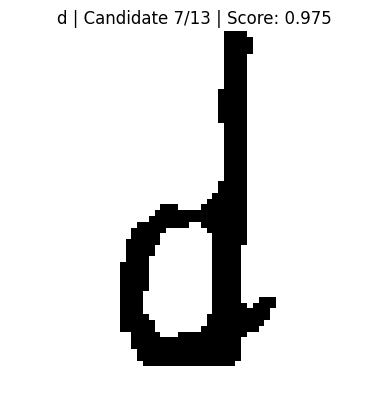

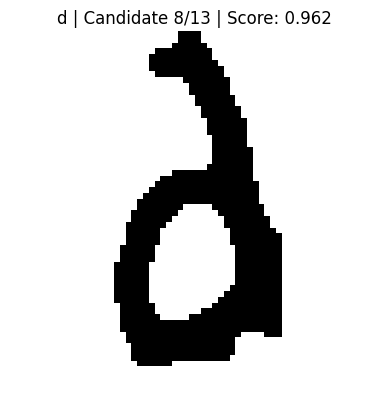

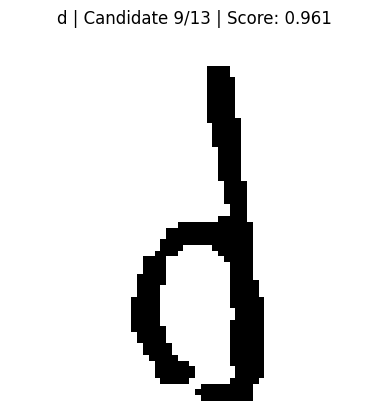

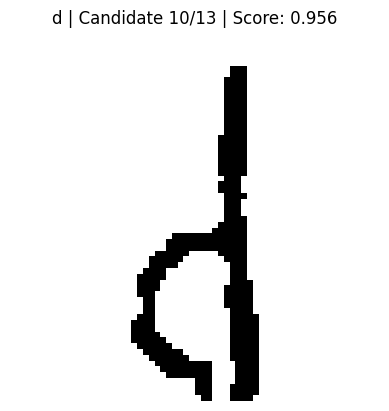

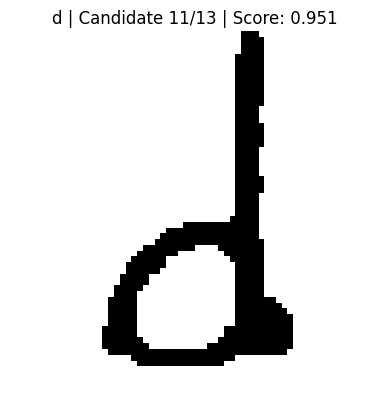

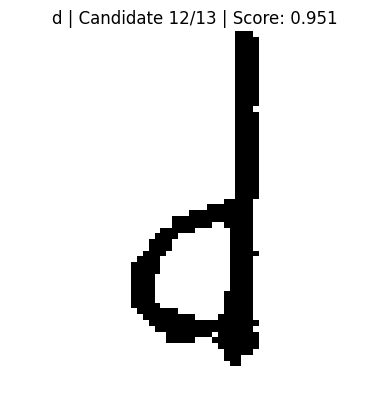

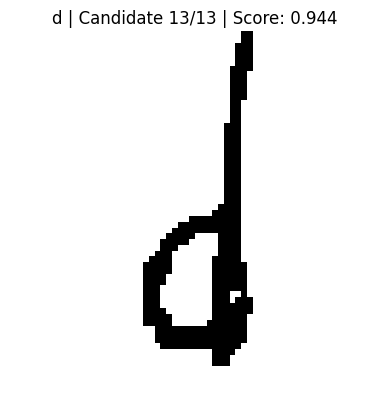

Select best candidate index (1-13) or 'skip': 7
✅ Selected Candidate 7/13

🔤 Label: e


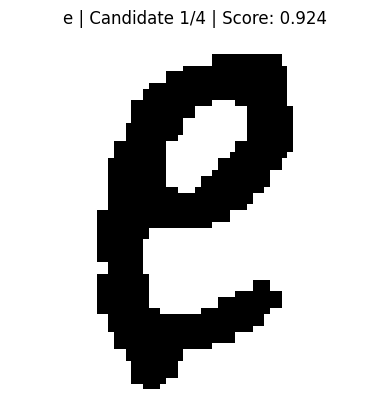

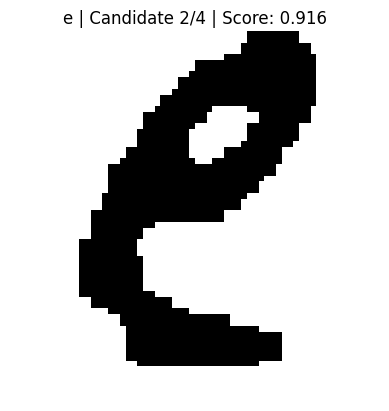

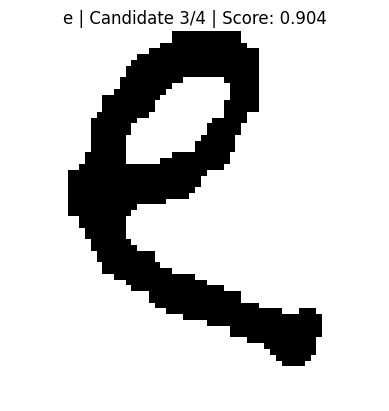

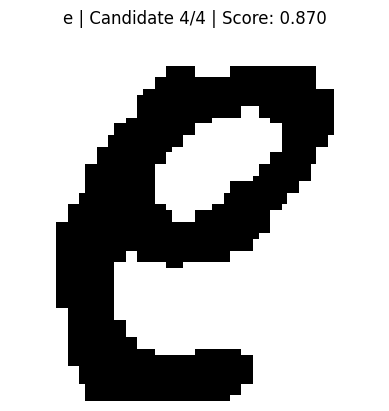

Select best candidate index (1-4) or 'skip': 4
✅ Selected Candidate 4/4

🔤 Label: f


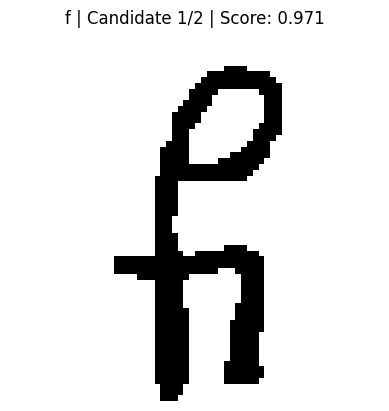

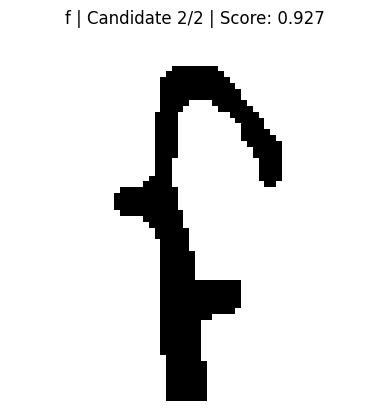

Select best candidate index (1-2) or 'skip': 2
✅ Selected Candidate 2/2

🔤 Label: h


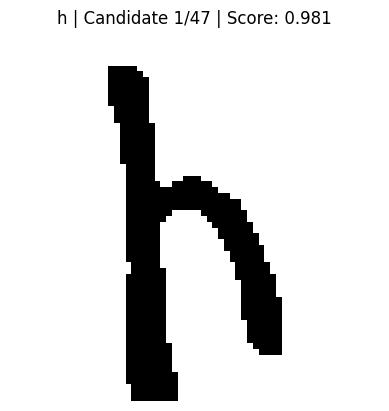

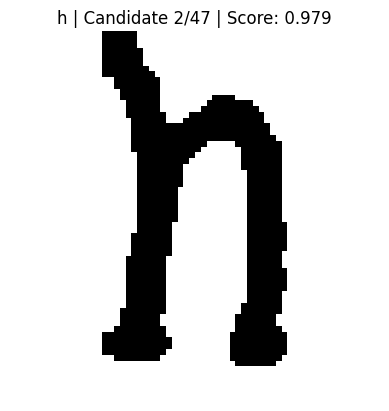

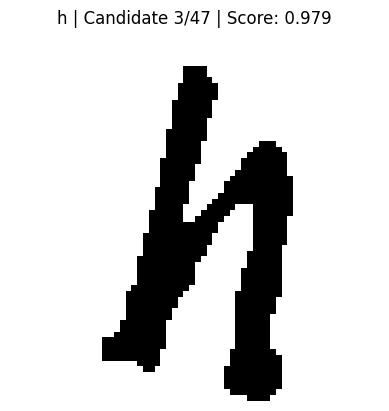

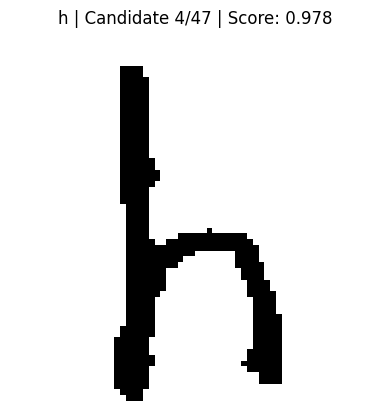

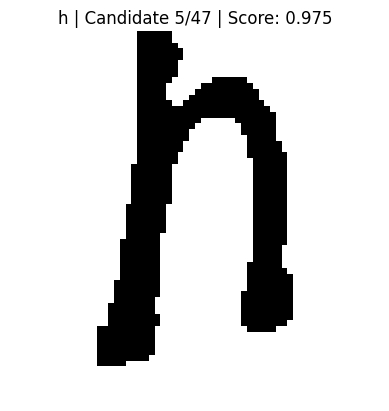

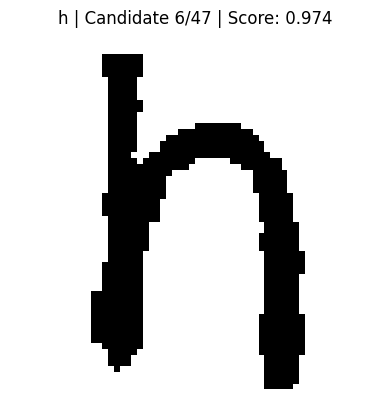

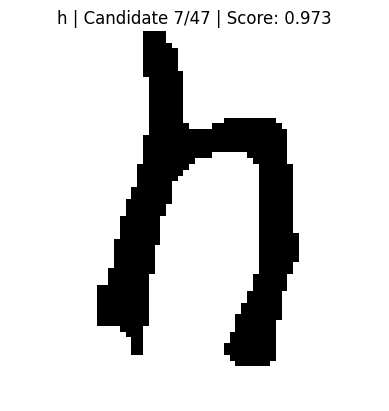

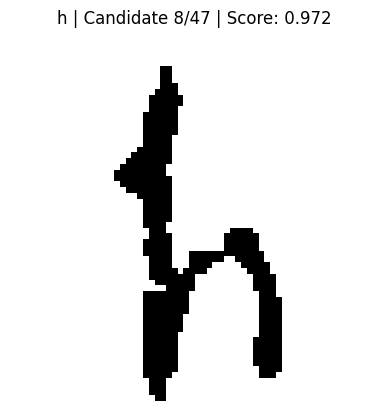

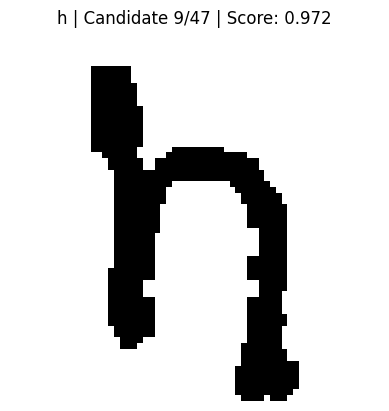

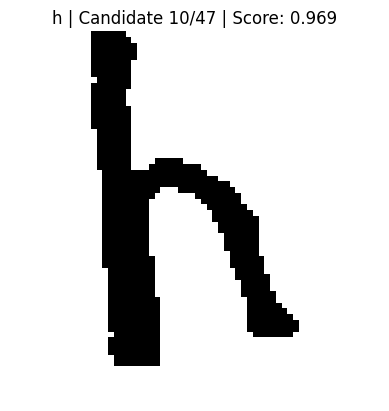

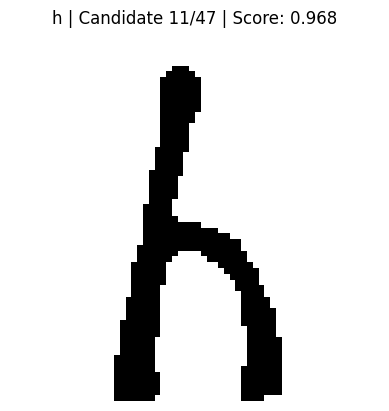

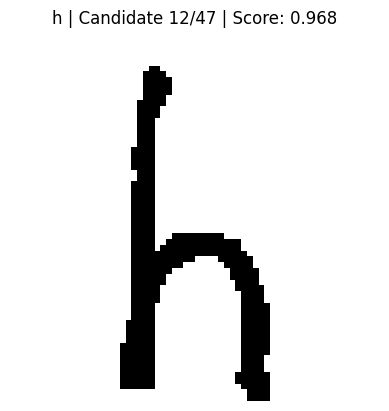

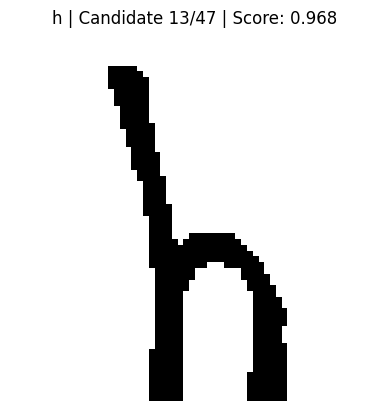

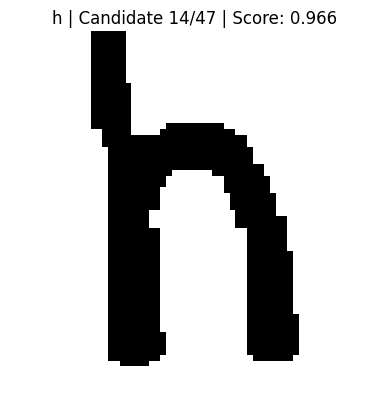

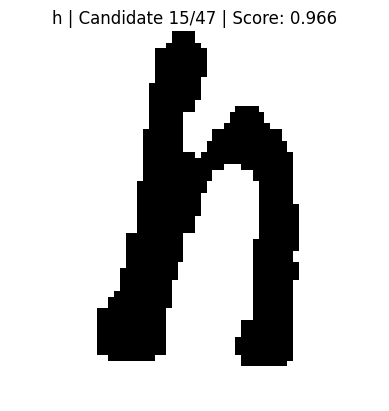

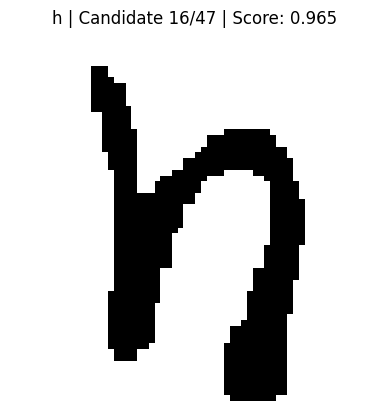

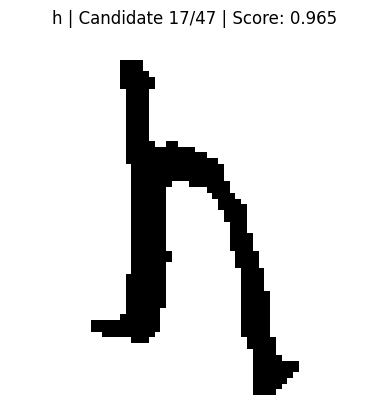

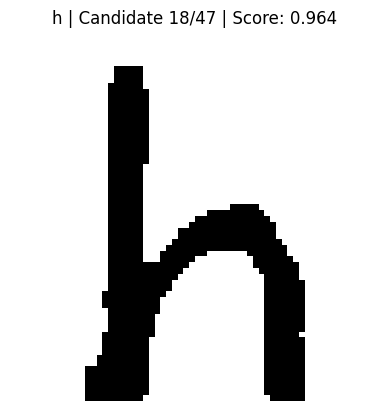

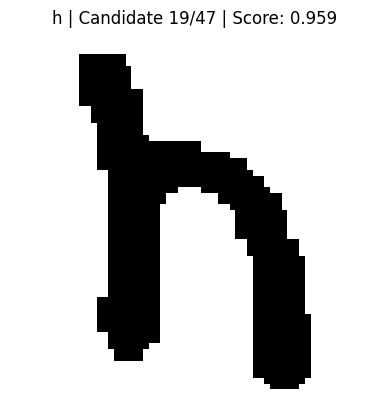

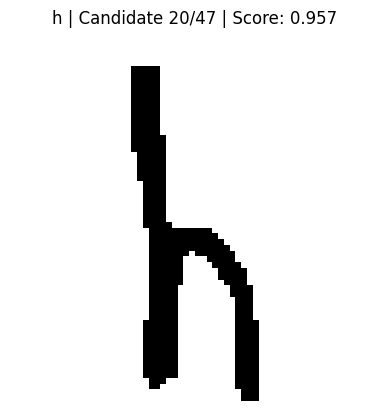

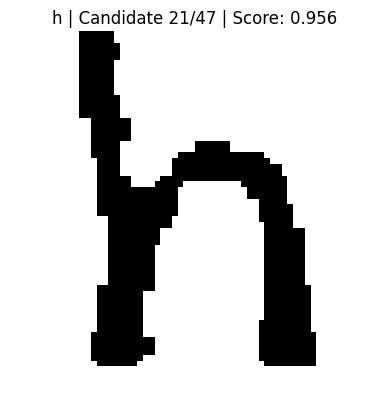

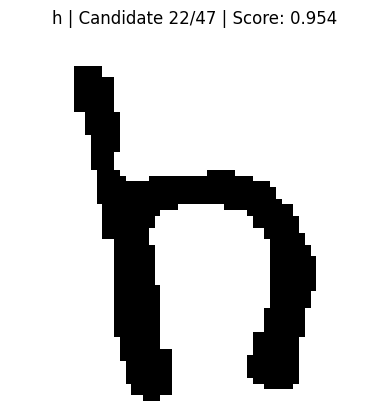

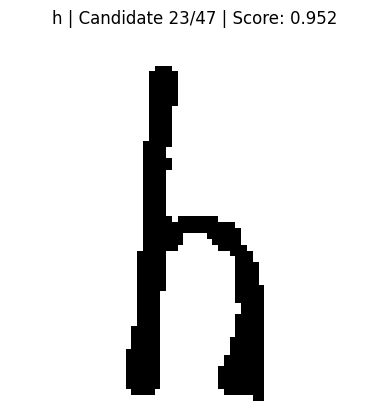

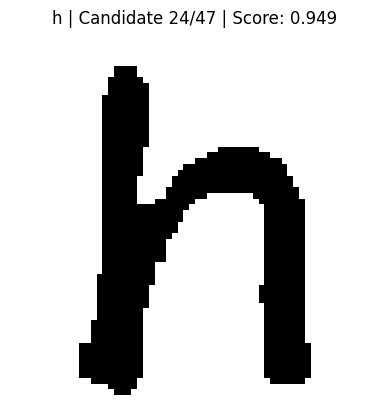

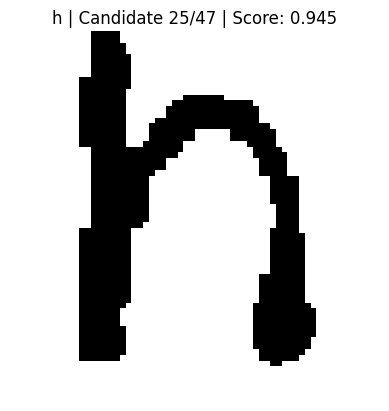

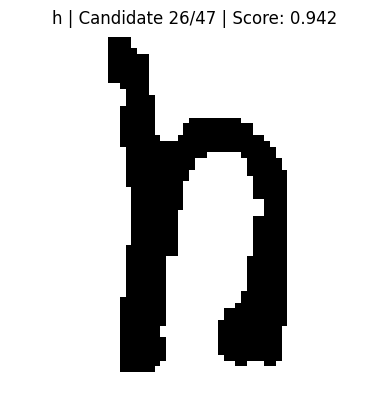

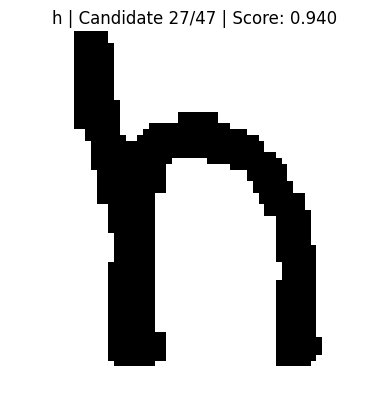

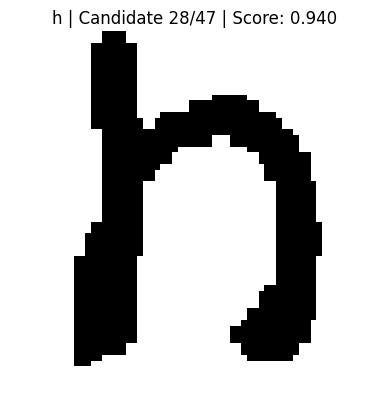

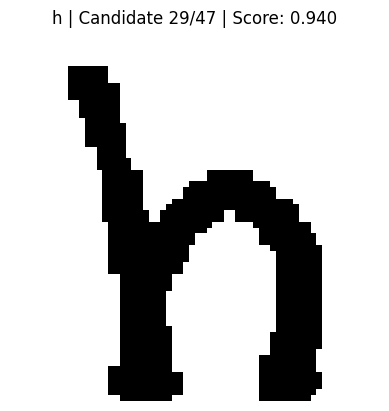

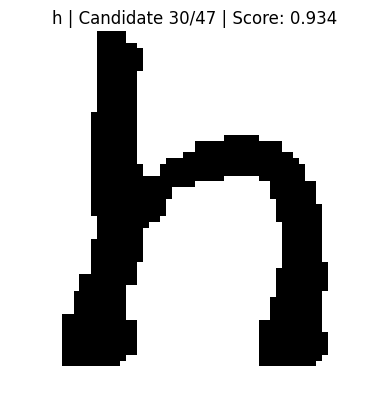

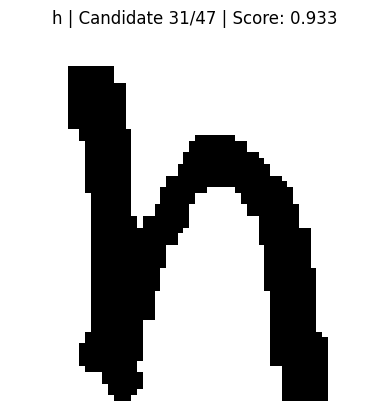

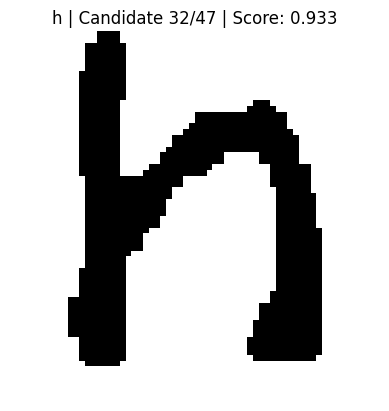

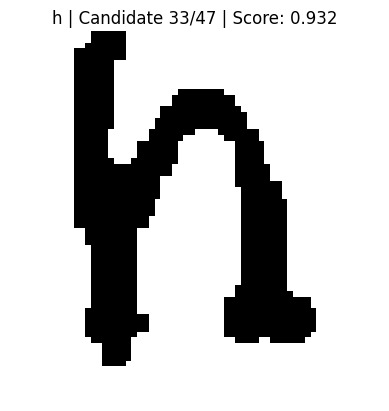

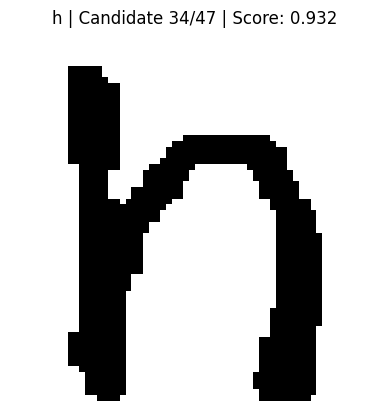

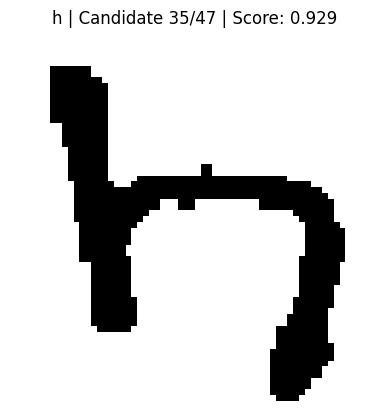

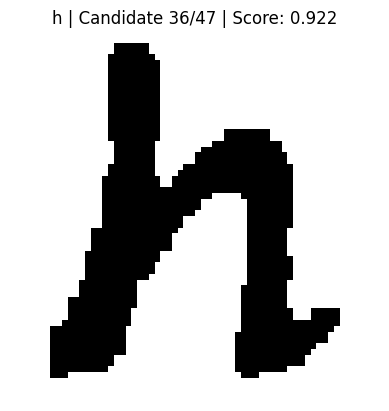

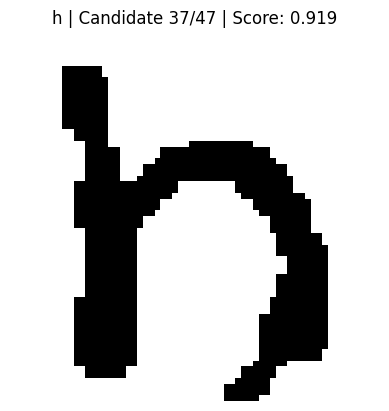

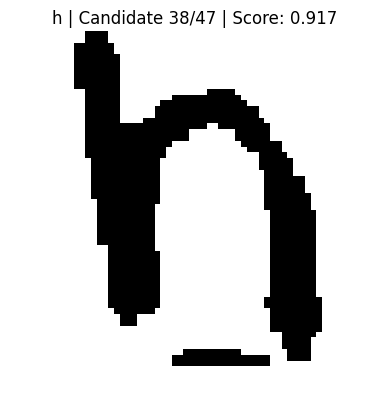

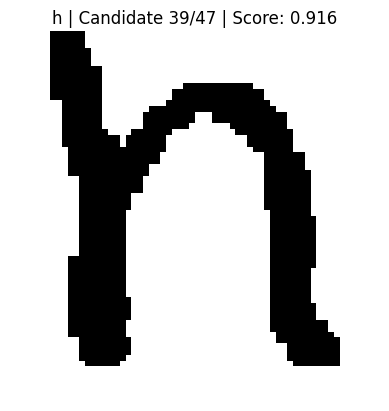

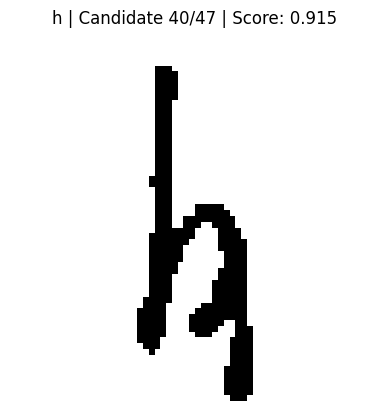

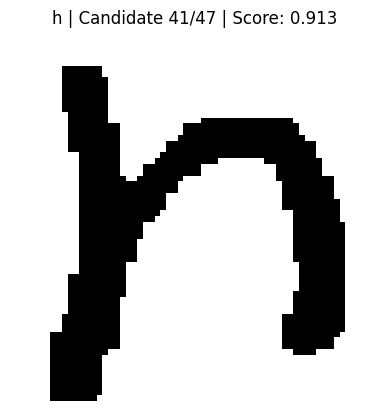

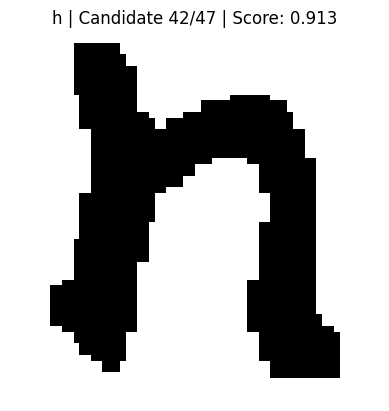

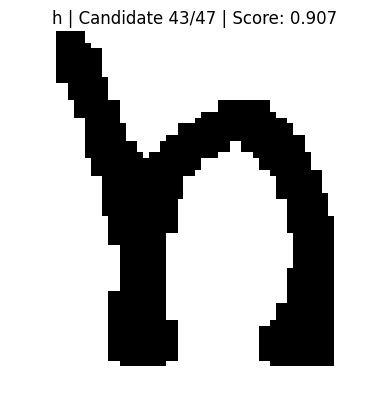

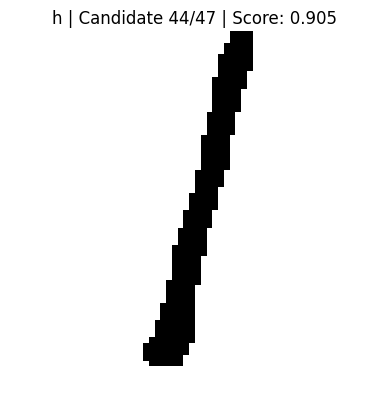

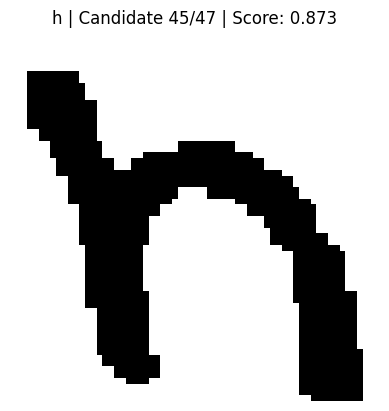

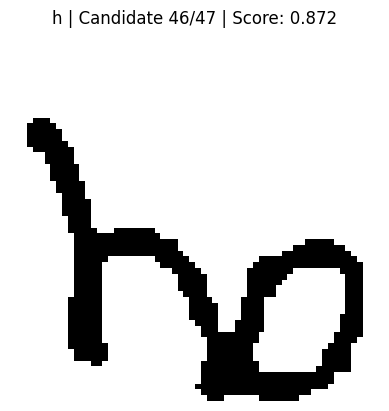

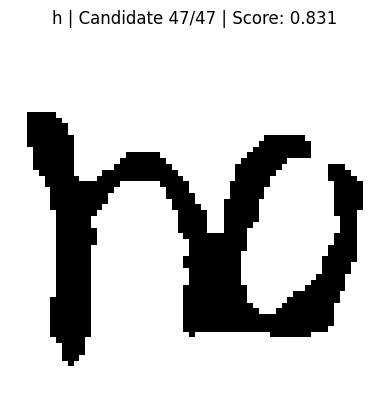

Select best candidate index (1-47) or 'skip': 13
✅ Selected Candidate 13/47

🔤 Label: k


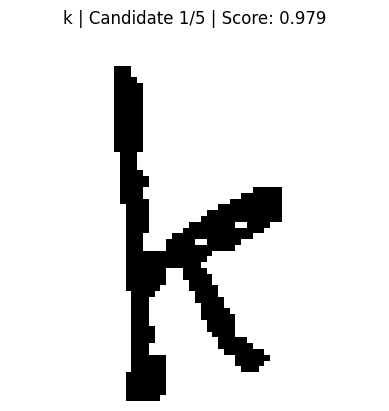

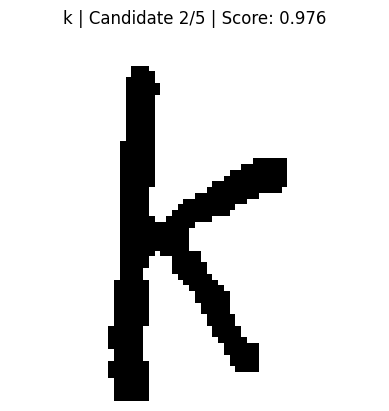

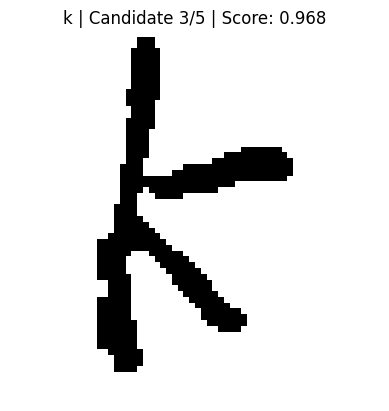

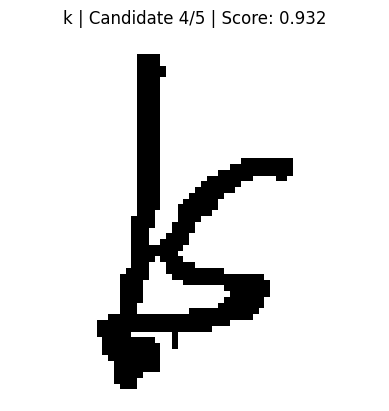

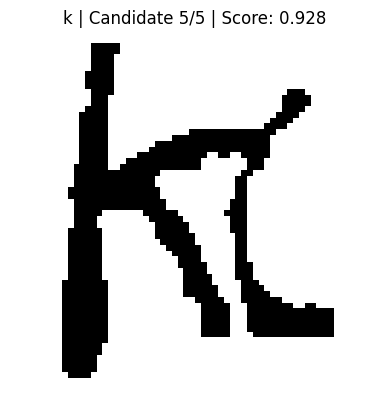

Select best candidate index (1-5) or 'skip': 2
✅ Selected Candidate 2/5

🔤 Label: m


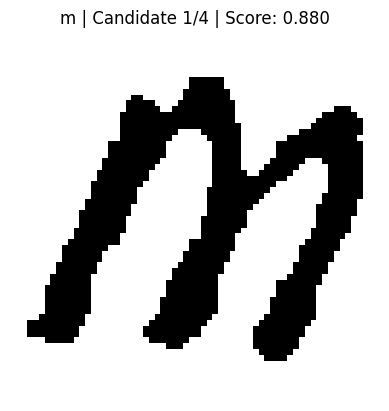

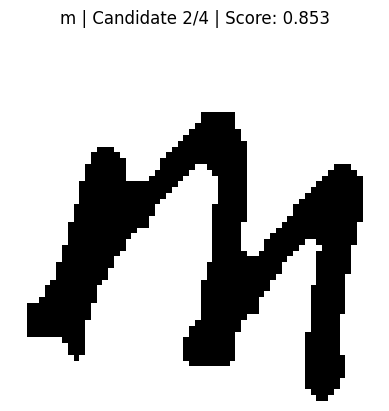

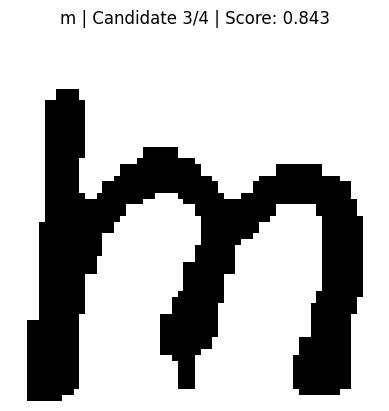

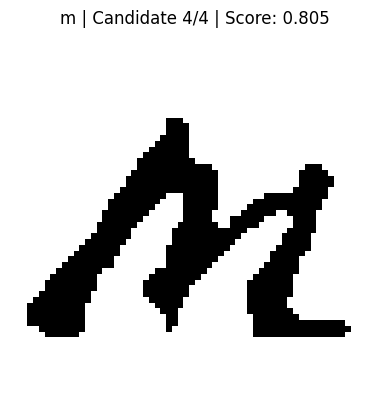

Select best candidate index (1-4) or 'skip': 3
✅ Selected Candidate 3/4

🔤 Label: n


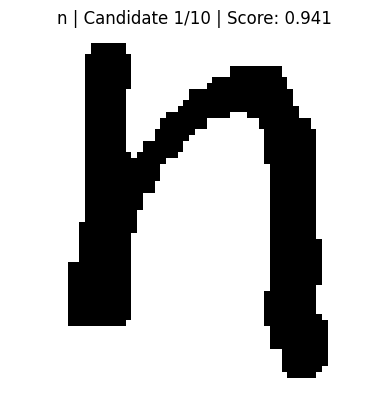

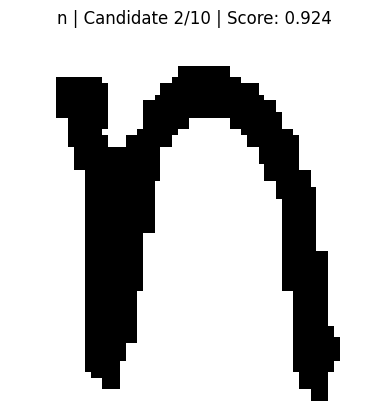

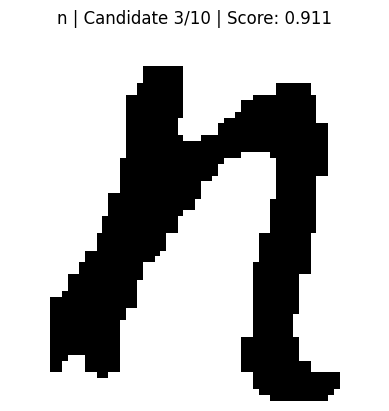

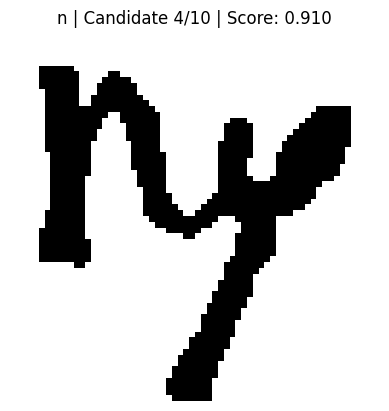

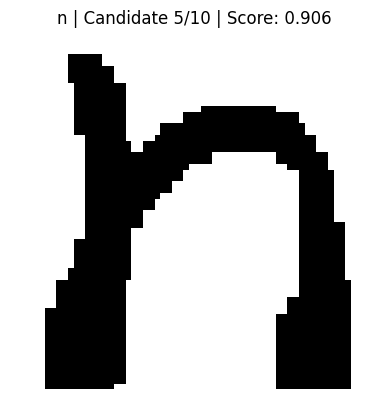

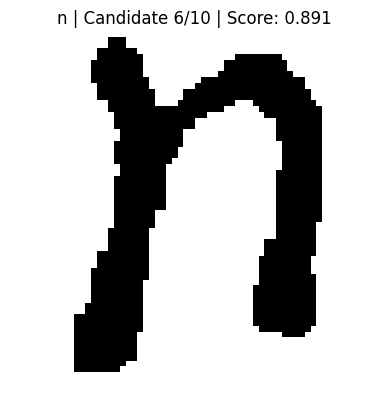

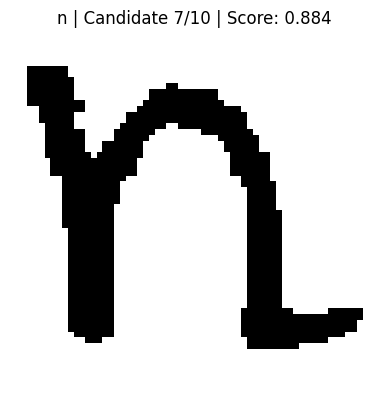

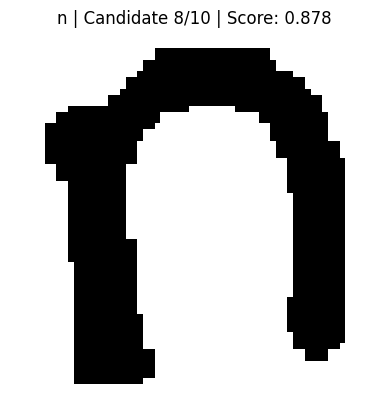

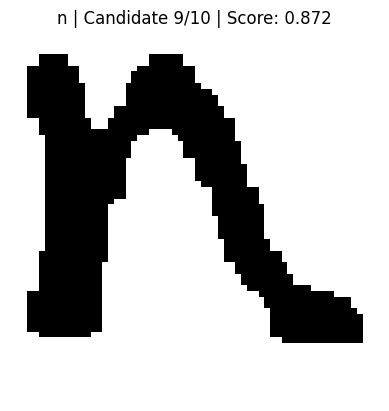

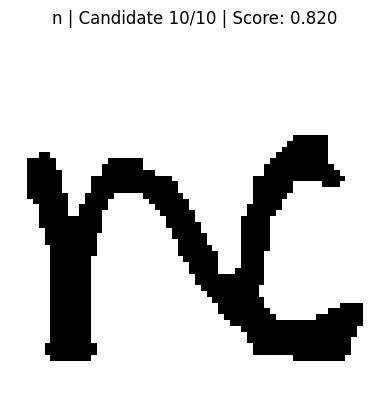

Select best candidate index (1-10) or 'skip': 7
✅ Selected Candidate 7/10

🔤 Label: p


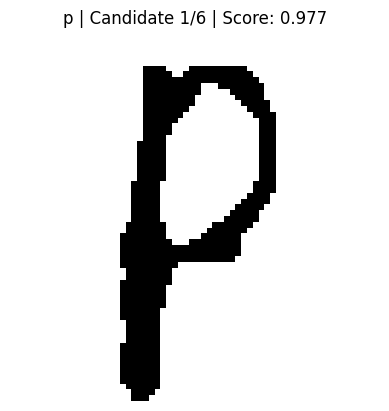

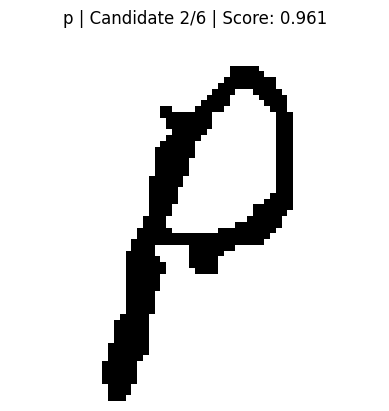

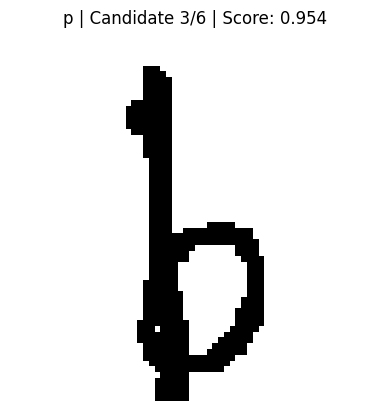

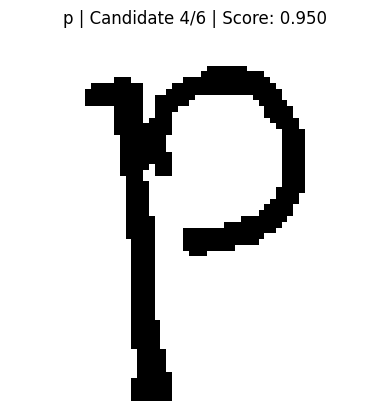

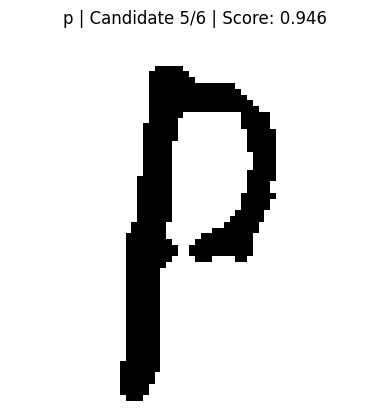

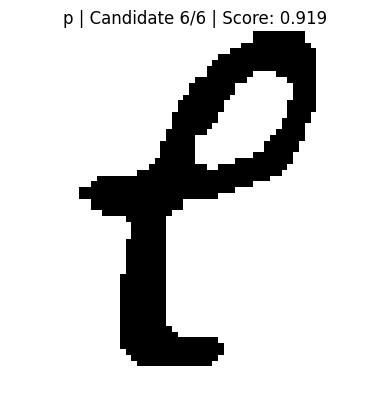

Select best candidate index (1-6) or 'skip': 1
✅ Selected Candidate 1/6

🔤 Label: q


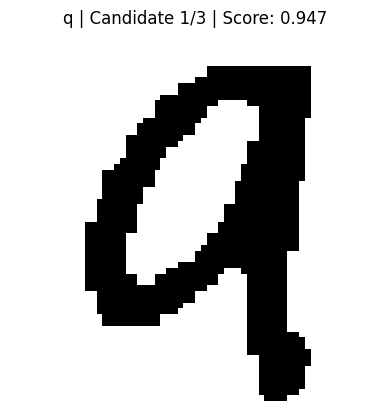

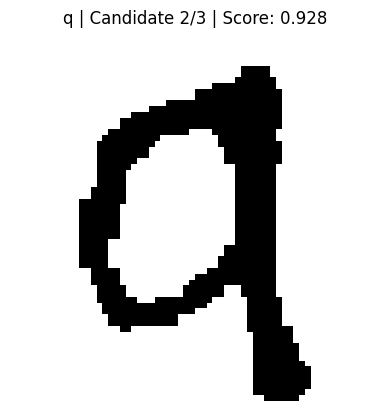

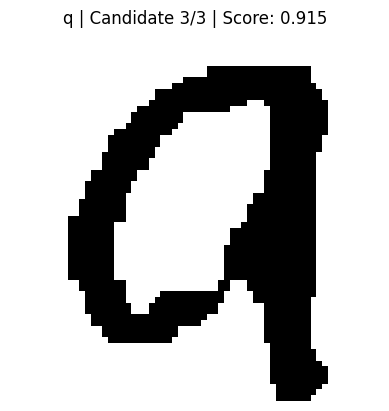

Select best candidate index (1-3) or 'skip': 1
✅ Selected Candidate 1/3

🔤 Label: t


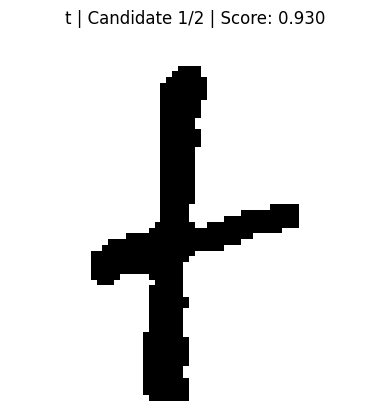

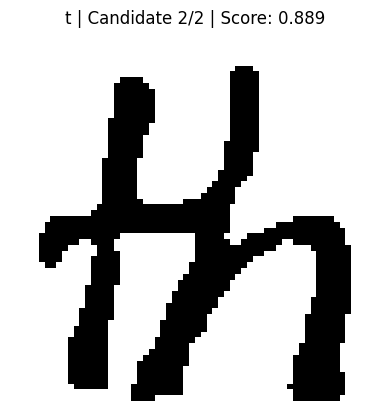

Select best candidate index (1-2) or 'skip': 1
✅ Selected Candidate 1/2

🔤 Label: x


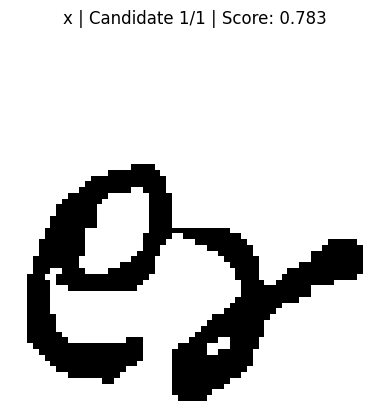

Select best candidate index (1-1) or 'skip': skip
⚠️ Skipped label: x

Interactive selection complete

➡️ Saving: kid15
⭐ Saved best (manual): kid15/0.png
⭐ Saved best (manual): kid15/1.png
⭐ Saved best (manual): kid15/4.png
⭐ Saved best (manual): kid15/6.png
⭐ Saved best (manual): kid15/capital_c.png
⭐ Saved best (manual): kid15/capital_g.png
⭐ Saved best (manual): kid15/capital_l.png
⭐ Saved best (manual): kid15/capital_p.png
⭐ Saved best (manual): kid15/capital_q.png
⭐ Saved best (manual): kid15/capital_s.png
⭐ Saved best (manual): kid15/capital_u.png
⭐ Saved best (manual): kid15/capital_w.png
⭐ Saved best (manual): kid15/small_a.png
⭐ Saved best (manual): kid15/small_d.png
⭐ Saved best (manual): kid15/small_e.png
⭐ Saved best (manual): kid15/small_g.png
⭐ Saved best (manual): kid15/small_h.png
⭐ Saved best (manual): kid15/small_n.png

➡️ Saving: kid2
⭐ Saved best (manual): kid2/0.png
⭐ Saved best (manual): kid2/1.png
⭐ Saved best (manual): kid2/2.png
⭐ Saved best (manual): kid2/3.p

In [ ]:
def run_pipeline():

    data = preprocess_images()
    data = segment_characters(data)
    data = label_characters(data)

    # HUMAN CONTROL STEP
    data = interactive_best_selection(data)

    # FINAL SAVE
    save_final_outputs(data)

run_pipeline()

In [ ]:
from google.colab import files

# 1. Zip the folder (syntax: !zip -r [target_filename] [source_folder])
!zip -r part1.zip /content/

# 2. Trigger the browser download
files.download('part1.zip')

  adding: content/ (stored 0%)
  adding: content/.config/ (stored 0%)
  adding: content/.config/gce (stored 0%)
  adding: content/.config/configurations/ (stored 0%)
  adding: content/.config/configurations/config_default (deflated 15%)
  adding: content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db (deflated 97%)
  adding: content/.config/.last_update_check.json (deflated 22%)
  adding: content/.config/.last_opt_in_prompt.yaml (stored 0%)
  adding: content/.config/logs/ (stored 0%)
  adding: content/.config/logs/2026.03.30/ (stored 0%)
  adding: content/.config/logs/2026.03.30/13.34.26.856841.log (deflated 58%)
  adding: content/.config/logs/2026.03.30/13.34.14.816231.log (deflated 58%)
  adding: content/.config/logs/2026.03.30/13.34.38.057647.log (deflated 57%)
  adding: content/.config/logs/2026.03.30/13.34.38.846859.log (deflated 56%)
  adding: content/.config/logs/2026.03.30/13.33.51.299064.log (deflated 92%)
  adding: content/.config/logs/2026.03.30/13.34

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>